In [1]:
# # 整理文件
# import os
# import shutil

# # 获取当前目录
# current_path = "C:\\Users\\zyx\\Desktop\\data\\CO_and_HCO\\HCOp"
# print('当前目录：' + current_path)

# # 获取当前目录下的所有文件名
# filename_list = os.listdir(current_path)
# print('当前目录下文件：', filename_list)
# print('正在分类整理进文件夹中...')

# # 遍历文件名列表
# for filename in filename_list:
#     if filename[-11]=="5":
#         # 移动文件到相应的文件夹
#         shutil.move(current_path + '\\' + filename, "C:\\Users\\zyx\\Desktop\\data\\CO_and_HCO\\HCOp_0.5arc")
#         print(filename + '转移成功！')
#     elif filename[-11]=="0":
#         shutil.move(current_path + '\\' + filename, "C:\\Users\\zyx\\Desktop\\data\\CO_and_HCO\\HCOp_10arc")
#         print(filename + '转移成功！')

# print('整理完毕！')


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import copy
from adjustText import adjust_text
from scipy.signal import find_peaks
from PIL import Image
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
#%matplotlib notebook


In [2]:
file_path = "C:\\Users\\zyx\\Desktop\\data\\CO_and_HCO\\source.vsys.dat"
import pandas as pd

# 假设文件格式：
# 列名: ID   Vsys   RA    Dec
# 数据: 001  250.3  12.5  30.0
# 注释行以 '#' 开头

df = pd.read_csv(
    file_path,
    sep='\s+',          # 按空格/制表符分隔
    comment='#',        # 忽略注释行
    header=0,           # 第一行为列名
    #names=['ID', 'Vsys', 'RA', 'Dec']  # 可选：手动指定列名
)

print(df)   # df.head()则默认输出前五行数据，在数据量大的时候可以方便检查

   source, field,        ra,       dec,       Vsys,  Vsys_sigma
0     Ll01   Ll01  81.505174 -67.503328  287.328125    0.983483
1     Ll02   Ll02  73.534500 -66.775389  274.113342    1.343082
2     Ll03   Ll03  84.478441 -69.576586  265.006836    0.913653
3     Ll04   Ll04  75.983875 -67.344111  269.604950    2.035654
4   Ll04_2   Ll04  75.982767 -67.345826  268.652863    1.179893
..     ...    ...        ...        ...         ...         ...
66     S07    S07  13.514352 -73.327366  163.216629    1.475220
67     S08    S08  12.257295 -73.186037  146.751221    1.218433
68     S09    S09  11.235079 -73.169770  132.257156    2.265169
69     S10    S10  16.280342 -71.995208  189.761490    1.967455
70   S10_2    S10  16.274230 -71.995216  190.884918    1.150420

[71 rows x 6 columns]


In [3]:
print(df.columns)
print(type(df))

Index(['source,', 'field,', 'ra,', 'dec,', 'Vsys,', 'Vsys_sigma'], dtype='object')
<class 'pandas.core.frame.DataFrame'>


In [4]:
sou=df["source,"].tolist()
V=df["Vsys,"].tolist()
print(sou)
print(V)
print(type(sou))
print(type(V))

['Ll01', 'Ll02', 'Ll03', 'Ll04', 'Ll04_2', 'Ll05', 'Ll06', 'Ll06_2', 'Ll06_3', 'Ll07', 'Ll07_2', 'Ll08', 'Ll09', 'Ll09_2', 'Ll09_3', 'Ll09_4', 'Ll09_5', 'Ll10', 'Ll10_2', 'Lm01', 'Lm02', 'Lm02_2', 'Lm02_3', 'Lm03', 'Lm04', 'Lm04_2', 'Lm04_3', 'Lm05', 'Lm05_2', 'Lm05_3', 'Lm06', 'Lm06_2', 'Lm06_3', 'Lm07', 'Lm07_2', 'Lm07_3', 'Lm08', 'Lm09', 'Lm10', 'Lh01', 'Lh01_2', 'Lh01_3', 'Lh02', 'Lh02_2', 'Lh02_3', 'Lh03', 'Lh04', 'Lh05', 'Lh05_2', 'Lh05_3', 'Lh05_4', 'Lh06', 'Lh07', 'Lh08', 'Lh08_2', 'Lh08_3', 'Lh08_4', 'Lh09', 'Lh10', 'S01', 'S01_2', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S10_2']
[287.328125, 274.1133423, 265.0068359, 269.60495, 268.6528625, 274.9273682, 231.8370972, 232.4548035, 235.1858368, 267.088623, 266.247467, 235.3066406, 283.1570435, 282.2198181, 285.8900146, 279.8934326, 281.043335, 249.9293213, 249.9293213, 276.4645691, 230.7684784, 230.9107971, 229.9667053, 296.7356262, 283.2704773, 282.0755615, 284.4465637, 236.2545319, 237.4716644, 233.84242

In [5]:
def open_file():
    path='C:\\Users\\zyx\\Desktop\\data\\CO_and_HCO\\HCOp_0.5arc_out_'  #设置存储路径
    files= os.listdir(path) #得到文件夹下的所有文件名称
    name_list=source_name(files) # 得到每个源的名字
    data=[]  # 建立空列表储存数据
    data_i=0 # 记录是第几个文件

    for file in files:  #按照顺序在 files 里面进行每一个文件的 数据名称 循环读取
        position = path+"\\"+file   # 打开第一个文件
        data.append([])
        with open(position, 'r') as f:
            line_num=0
            for line in f:
                if line_num>0:
                    data[data_i].append(line.strip().split())
                line_num+=1
        data_i+=1
    return data,name_list

In [6]:
def source_name(name):
    name_list=[]
    for i in range(len(name)):
        part=name[i].split(".")
        name_list.append(part[1])
    return name_list

In [7]:
def data_to_xy(data):   # 输入某一个文件的数据，转换成xy
    data_x=[]
    data_y=[]
    for i in range(len(data)):
        data_x.append(float(data[i][0]))
        data_y.append(float(data[i][1]))
    return data_x,data_y

In [8]:
def paint(x,y):    # 把光谱画出来
    plt.plot(x,y)
    plt.xlabel("velocity (km/s)")
    plt.ylabel("flux (Jy/beam)")
    #plt.autoscale(enable=True, axis='y', tight=True)
    plt.ticklabel_format(useOffset=False, style='plain')
    plt.show()

In [9]:
def noise_sigma(raw_data,a):
    noise=raw_data[a:a+100]   
    noise_x,noise_y=data_to_xy(noise)
    paint(noise_x,noise_y)
    return noise_y

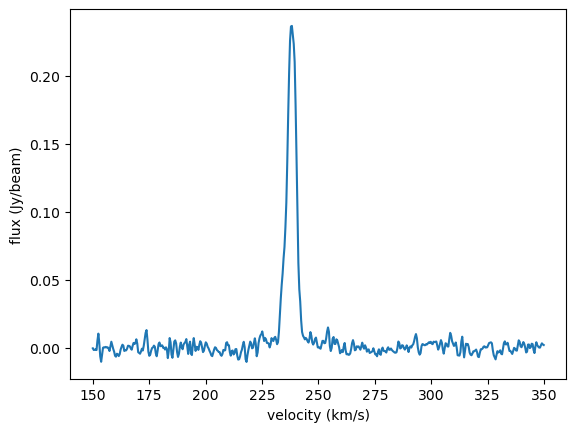

0
Lh01
488


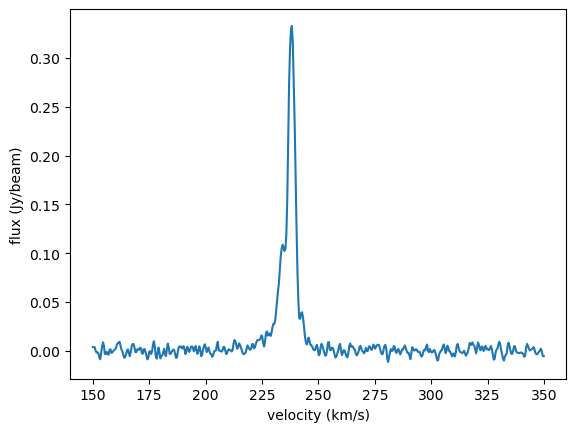

1
Lh02
488


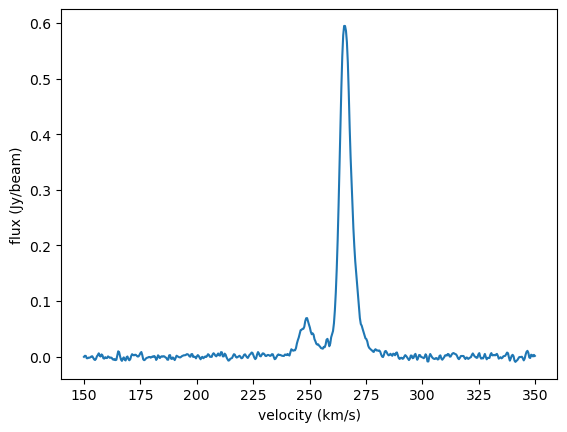

2
Lh03
488


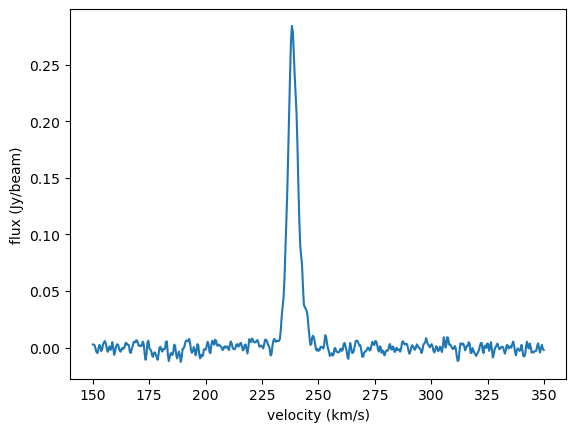

3
Lh04
488


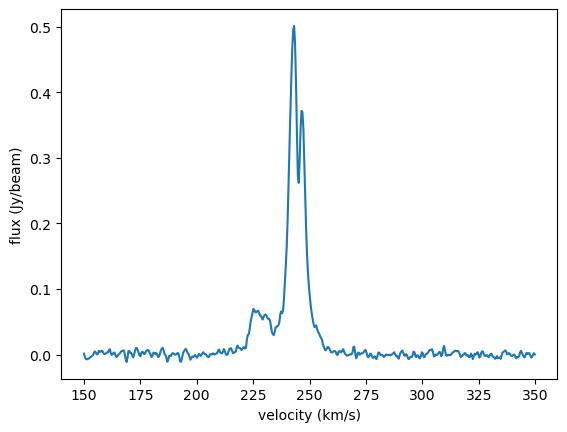

4
Lh05
488


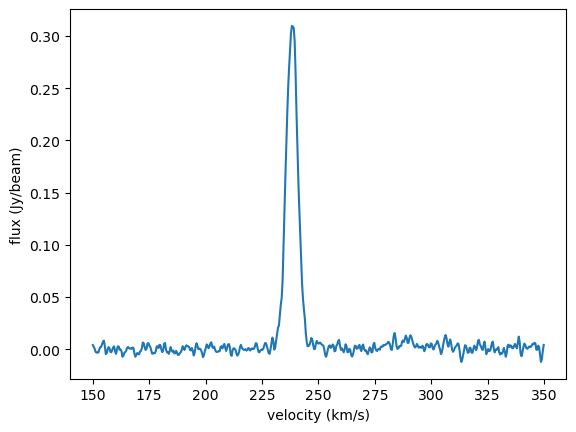

5
Lh06
488


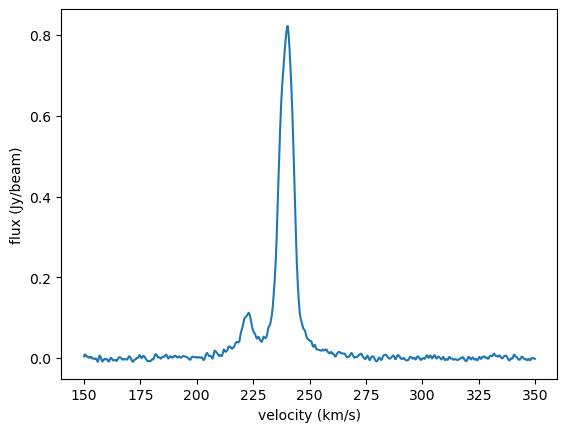

6
Lh07
488


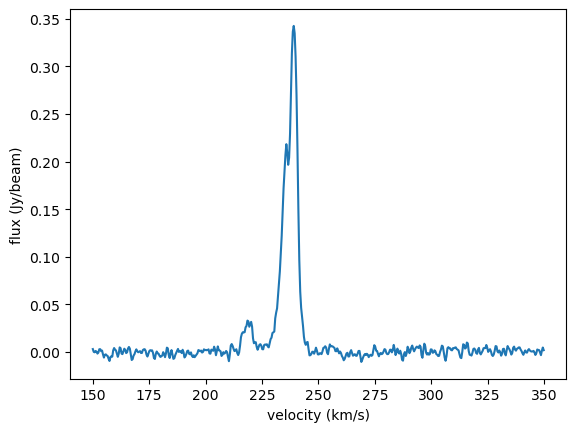

7
Lh08
488


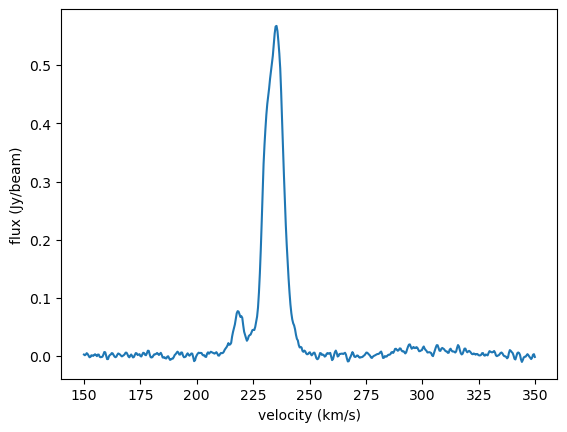

8
Lh09
488


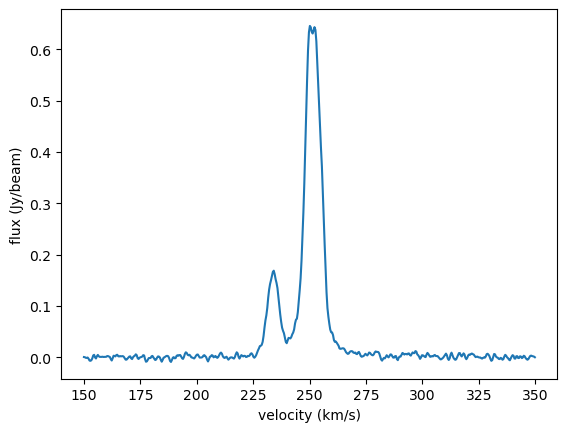

9
Lh10
488


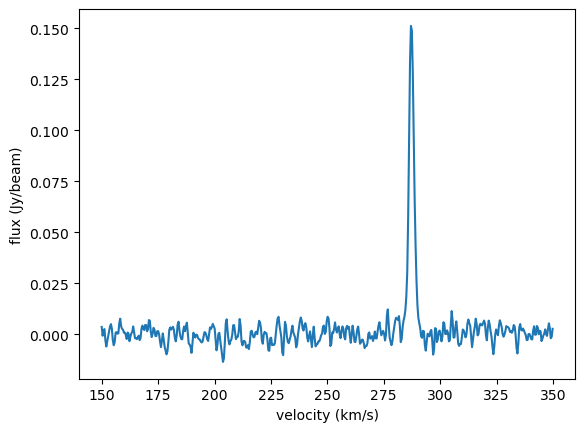

10
Ll01
488


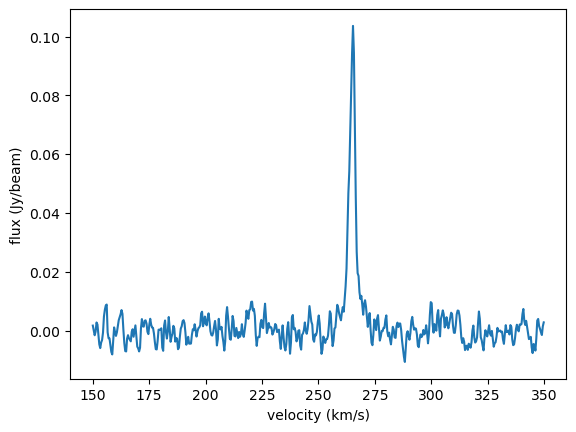

11
Ll03
488


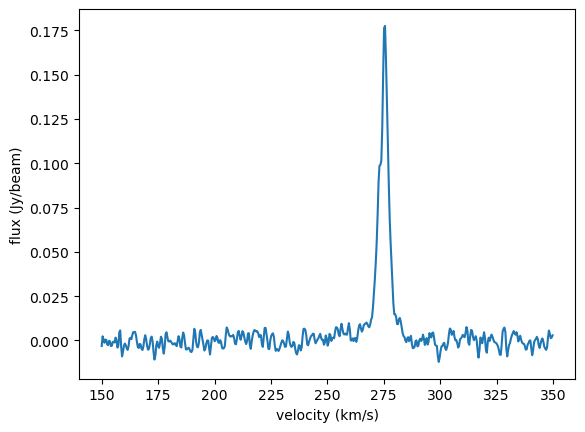

12
Ll05
488


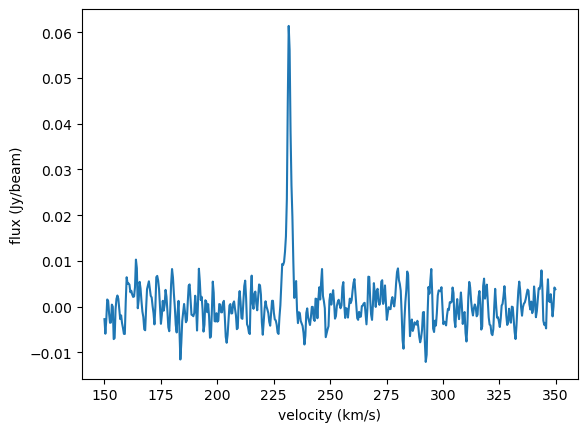

13
Ll06
488


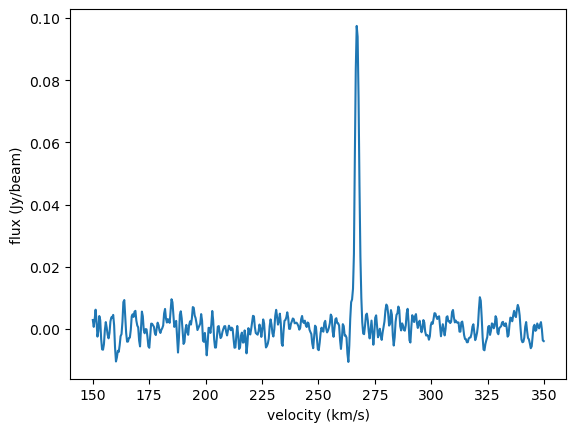

14
Ll07
488


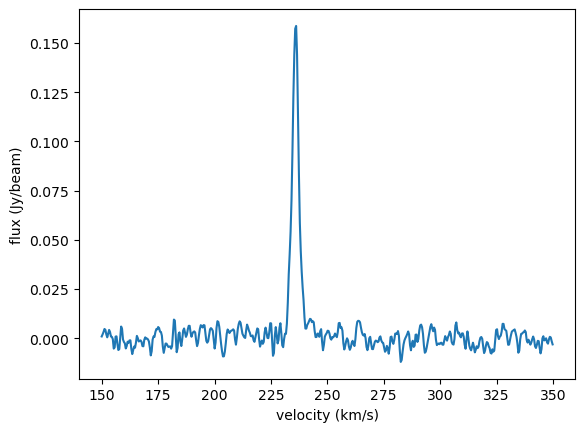

15
Ll08
488


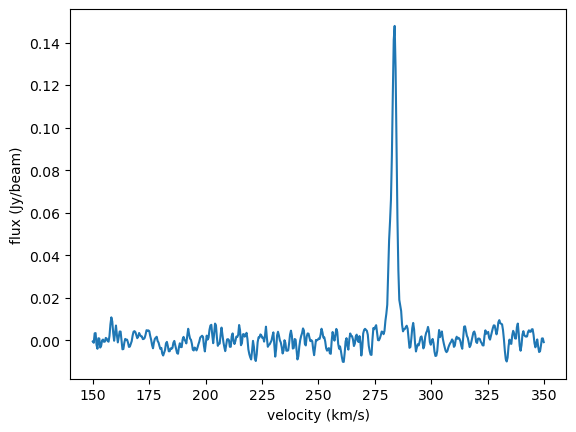

16
Ll09
488


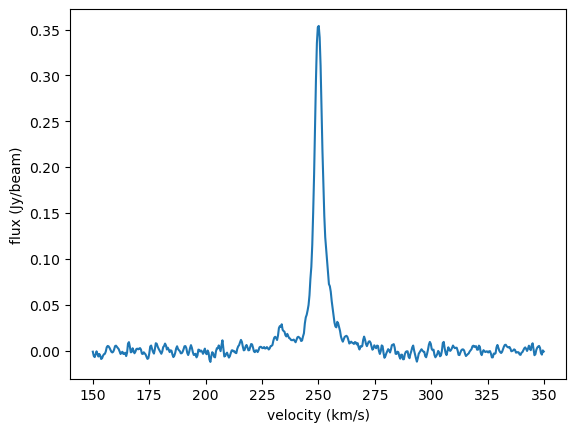

17
Ll10
488


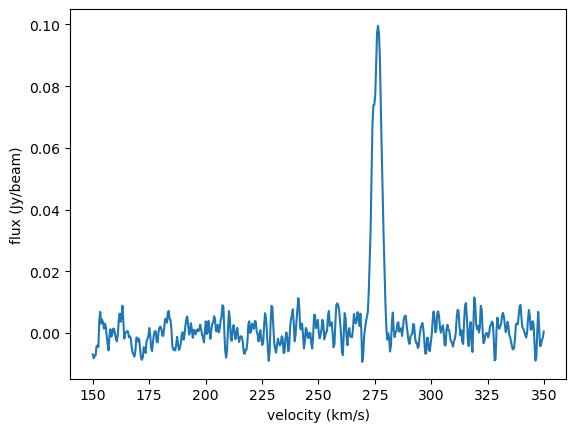

18
Lm01
488


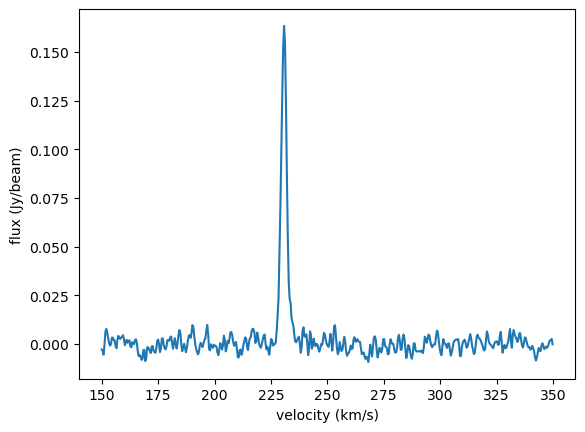

19
Lm02
488


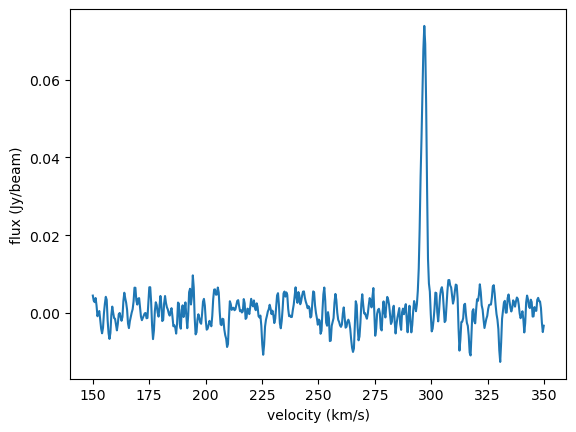

20
Lm03
488


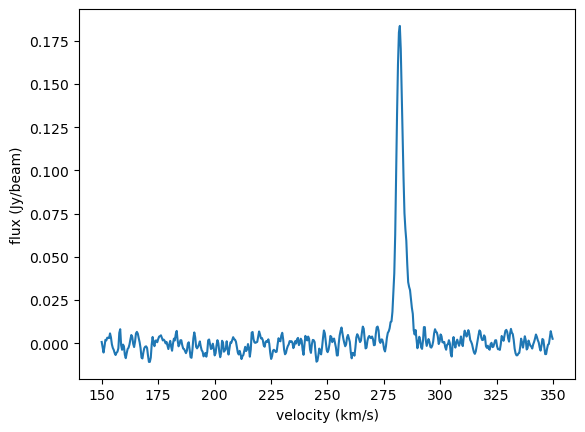

21
Lm04
488


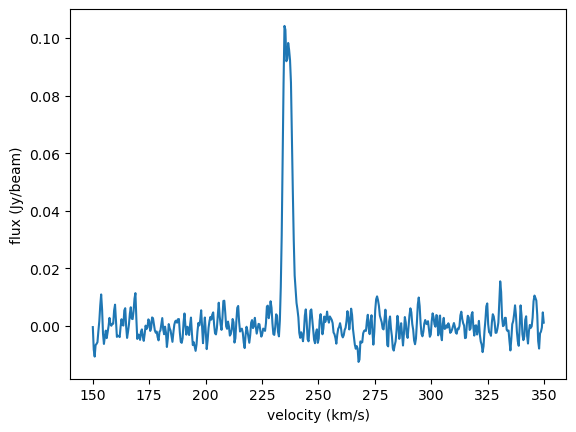

22
Lm05
488


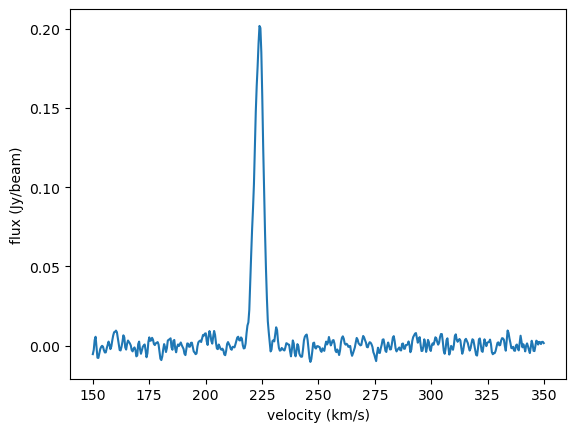

23
Lm06
488


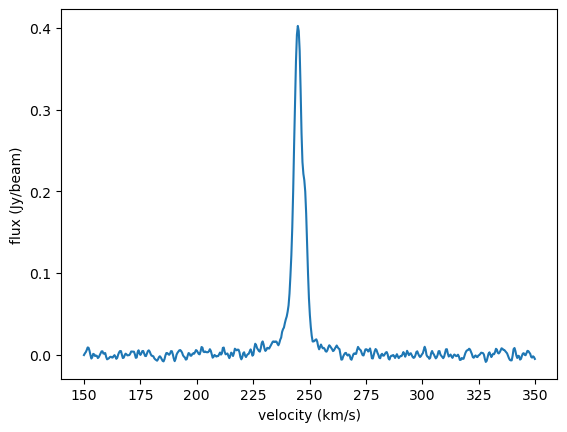

24
Lm07
488


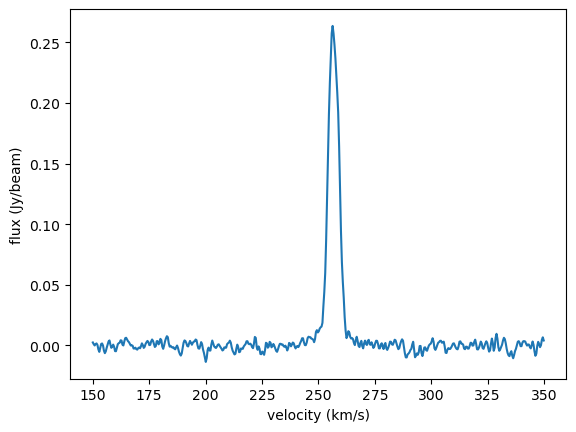

25
Lm08
488


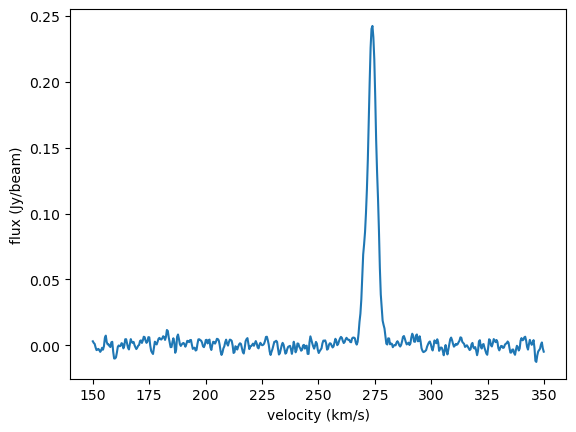

26
Lm09
488


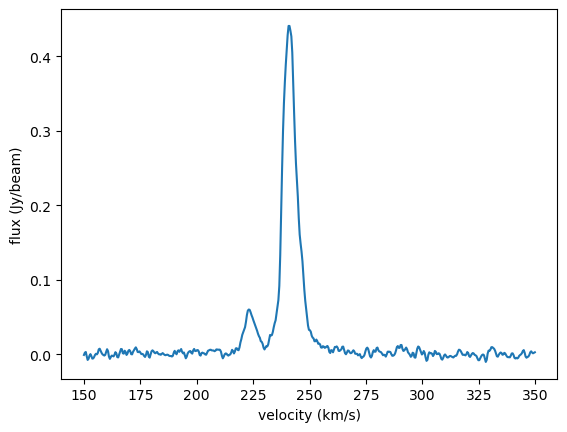

27
Lm10
488


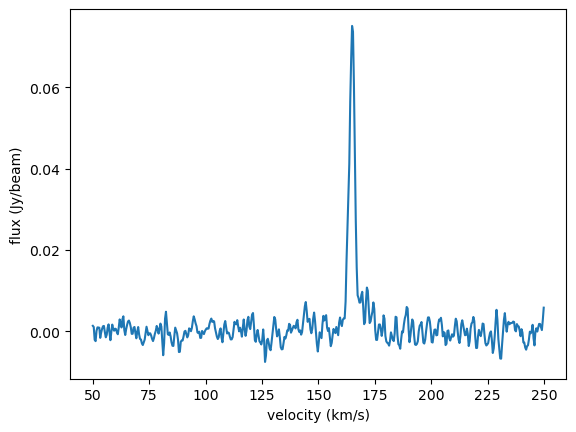

28
S01
488


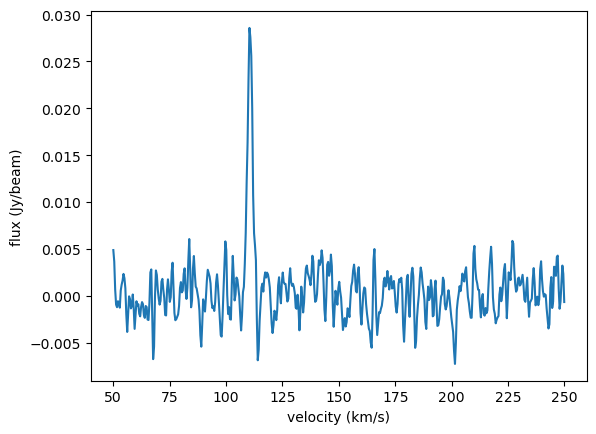

29
S02
488


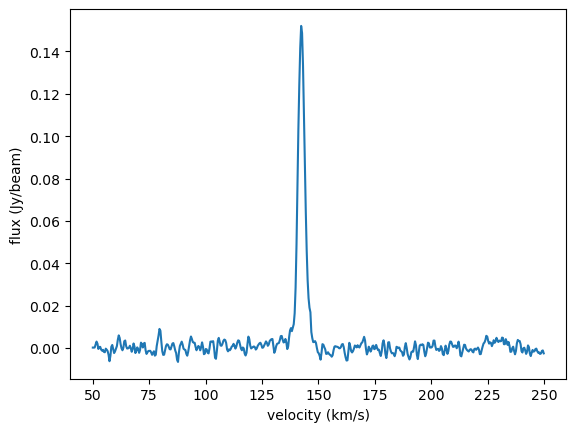

30
S03
488


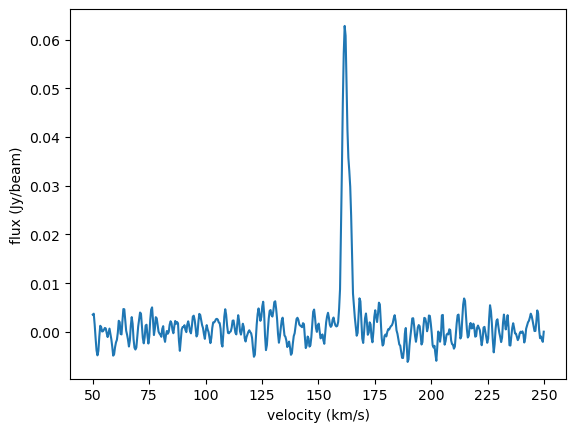

31
S04
488


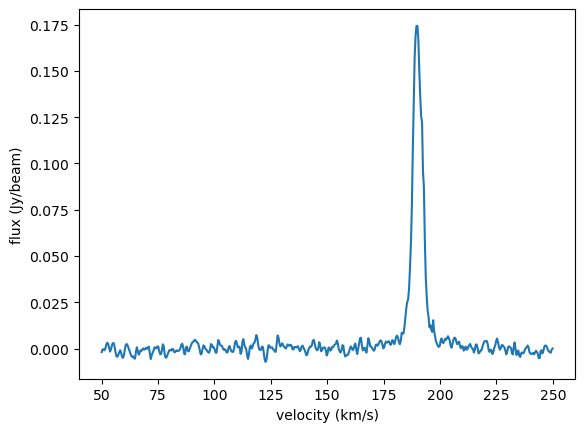

32
S05
488


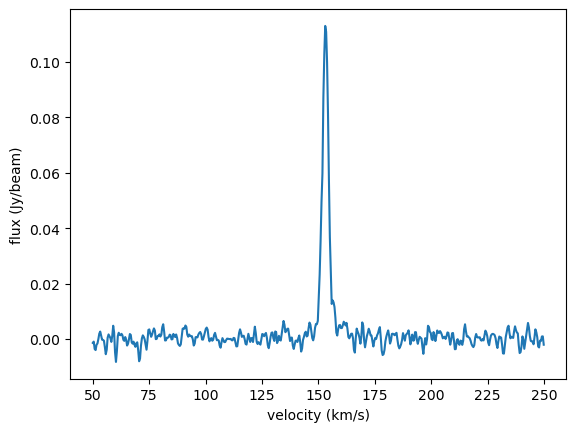

33
S06
488


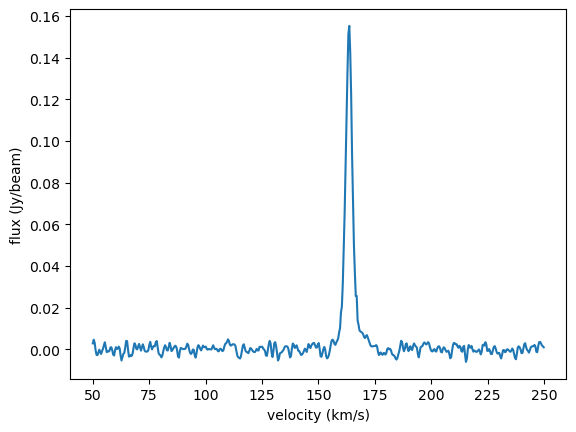

34
S07
488


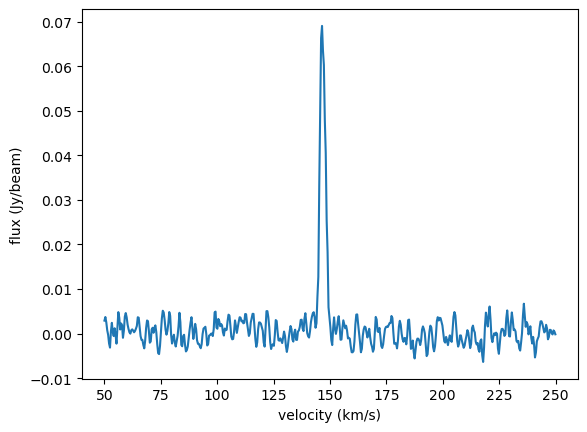

35
S08
488


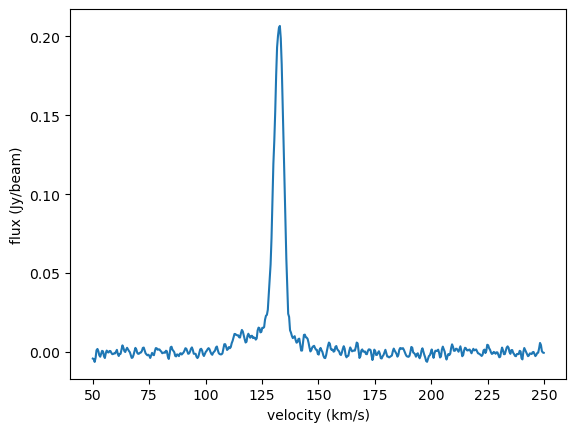

36
S09
488


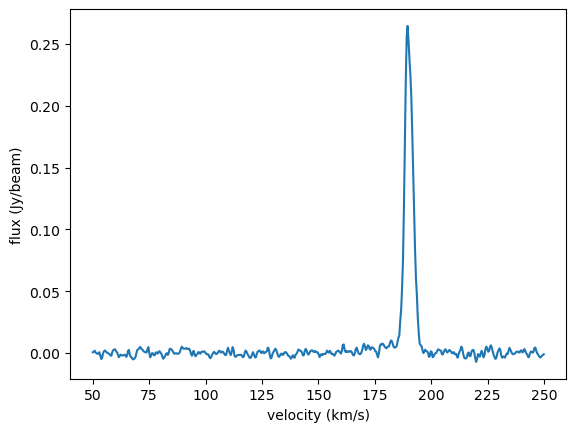

37
S10
488
38
38
38
38


In [10]:
data,name_list=open_file()
data.pop(11)
name_list.pop(11)
data.pop(12)
name_list.pop(12)
# data.pop(36)
# name_list.pop(36)
# print(data)
# print(len(data))
for i in range(len(data)):
    x,y=data_to_xy(data[i])
    paint(x,y)
    print(i)
    print(name_list[i])
    print(len(data[i]))
print(len(data))
print(len(name_list))
print(len(data))
print(len(name_list))

In [11]:
# 保存HCO+谱线的高度，用来归一化所有谱线
flux_HCO=[]
name_HCO=[]

for i in range(len(data)):
    x,y=data_to_xy(data[i])
    name_HCO.append(name_list[i])
    flux_HCO.append(max(y))
    
np.savetxt('data_with_HCO_flux.txt', 
           np.column_stack([name_HCO,flux_HCO]),fmt="%s", delimiter=' ',header="name flux")
print(name_HCO)
print(flux_HCO)

['Lh01', 'Lh02', 'Lh03', 'Lh04', 'Lh05', 'Lh06', 'Lh07', 'Lh08', 'Lh09', 'Lh10', 'Ll01', 'Ll03', 'Ll05', 'Ll06', 'Ll07', 'Ll08', 'Ll09', 'Ll10', 'Lm01', 'Lm02', 'Lm03', 'Lm04', 'Lm05', 'Lm06', 'Lm07', 'Lm08', 'Lm09', 'Lm10', 'S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10']
[0.236722291, 0.332697213, 0.594777167, 0.284221739, 0.50144136, 0.309614241, 0.822760761, 0.342617989, 0.567353308, 0.645932913, 0.151109248, 0.103599511, 0.177517712, 0.0613674298, 0.0974844024, 0.158679515, 0.147837862, 0.353915006, 0.0995358974, 0.163344994, 0.0738406479, 0.183654696, 0.104190871, 0.201626703, 0.402454019, 0.263523281, 0.24253118, 0.44099158, 0.0751578659, 0.028581392, 0.152063936, 0.0628216565, 0.174288481, 0.112904117, 0.155170918, 0.0690230802, 0.206649378, 0.264712214]


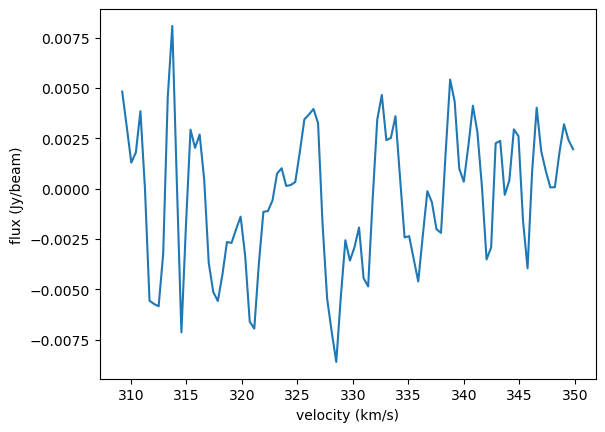

0


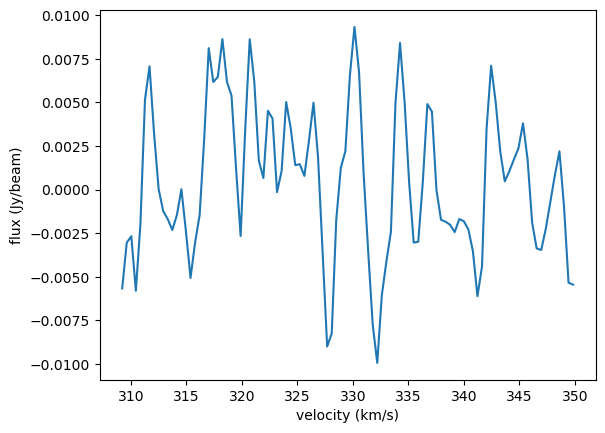

1


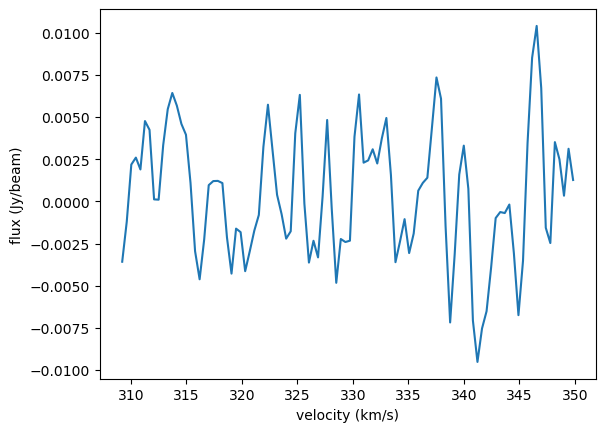

2


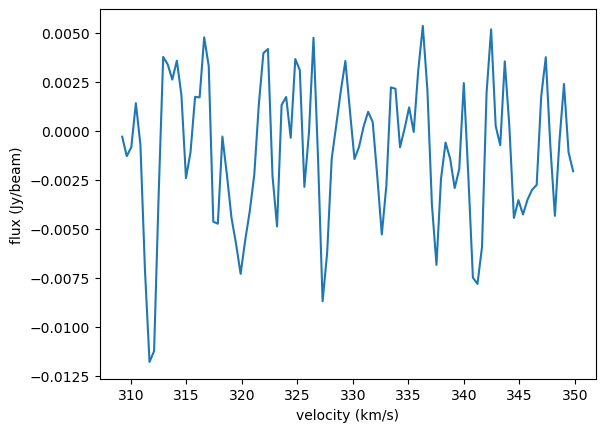

3


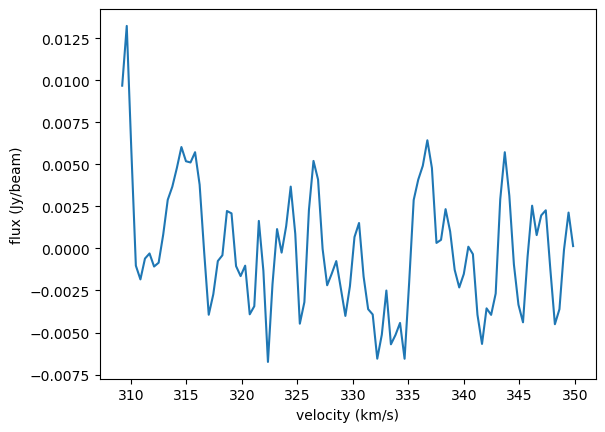

4


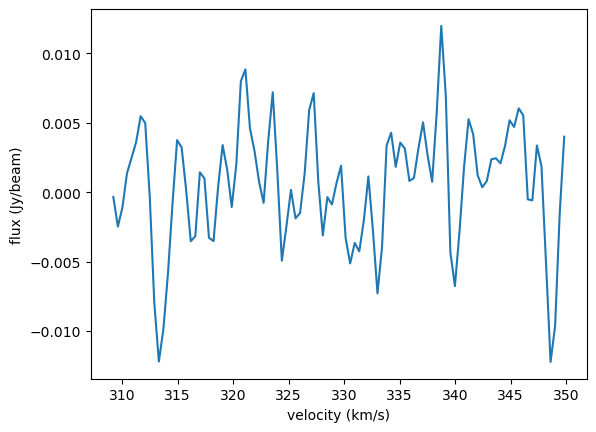

5


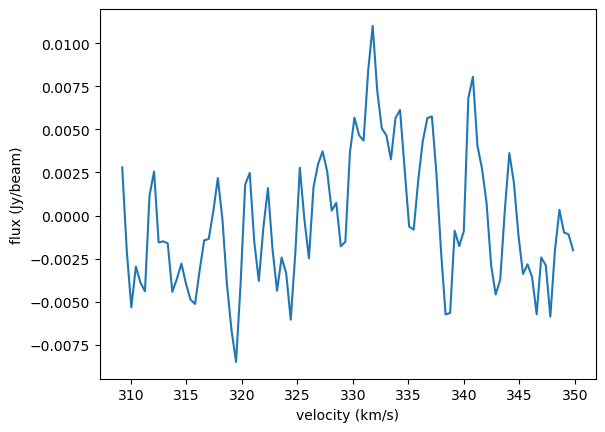

6


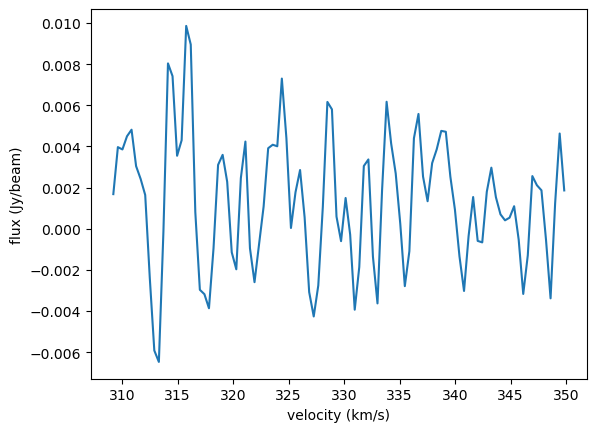

7


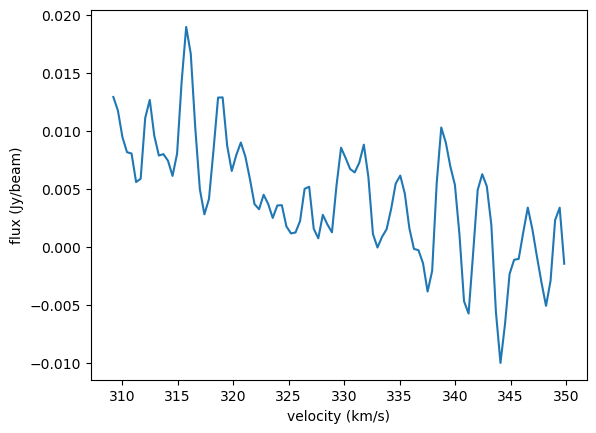

8


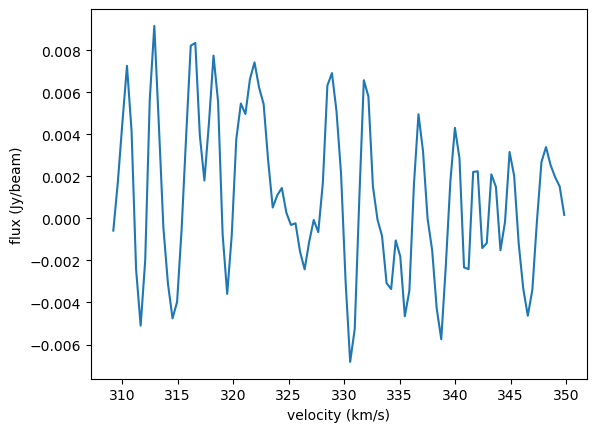

9


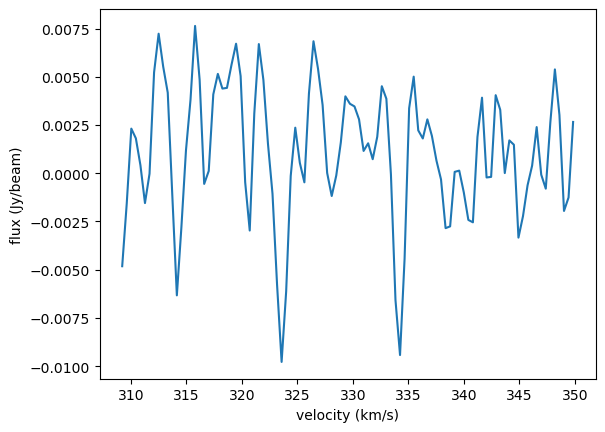

10


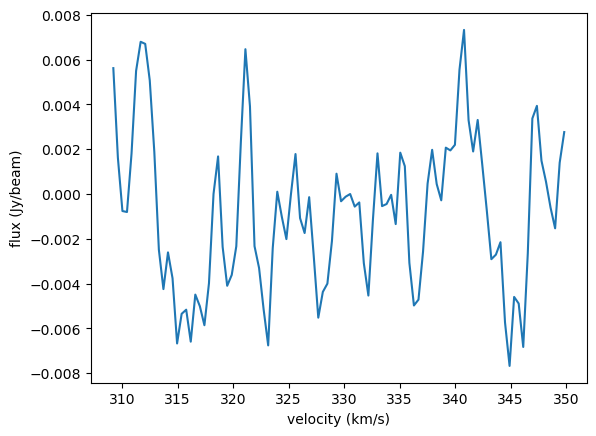

11


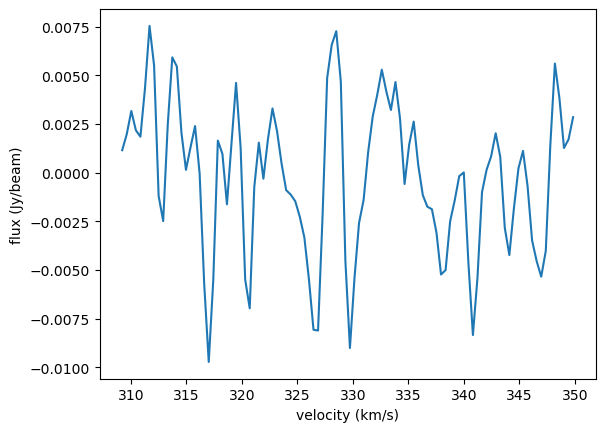

12


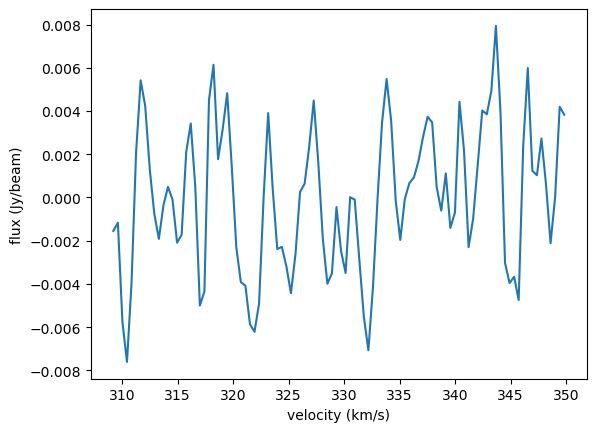

13


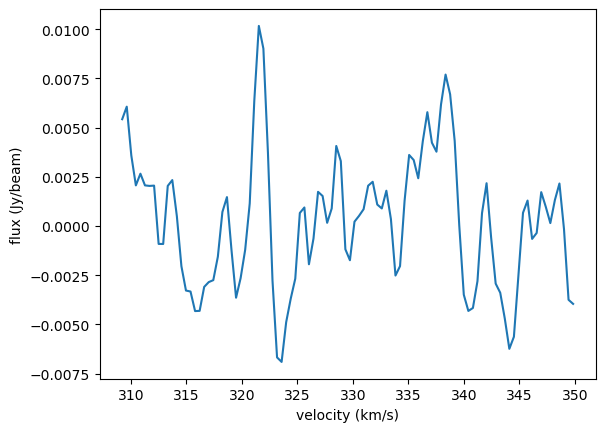

14


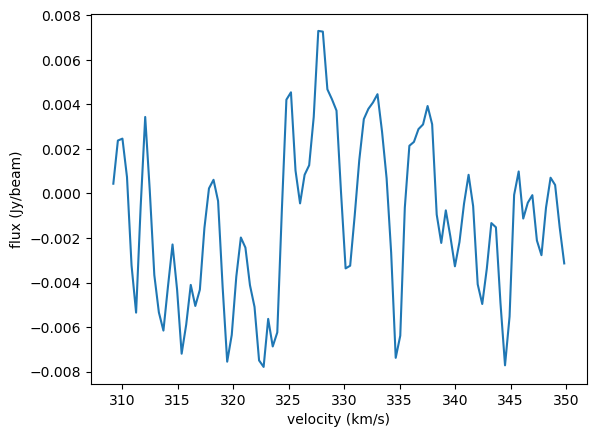

15


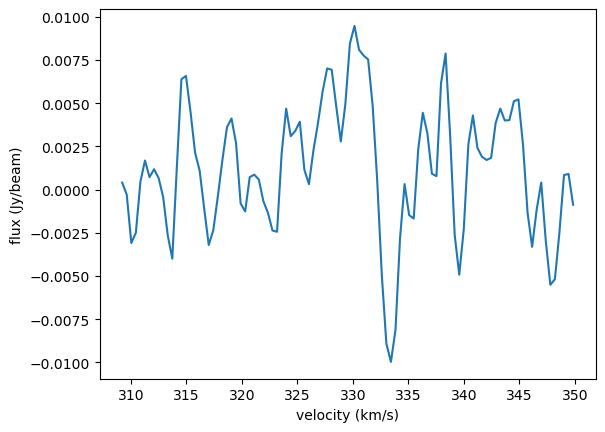

16


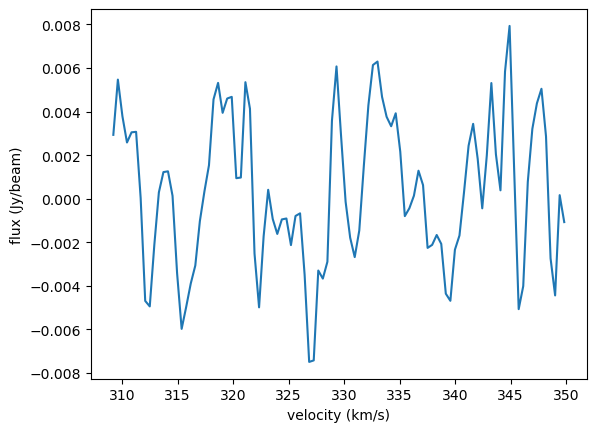

17


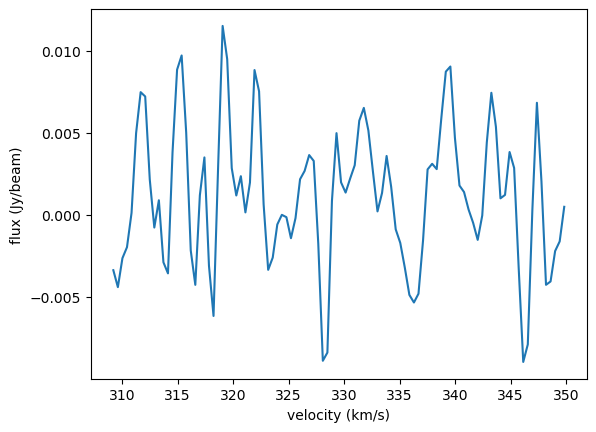

18


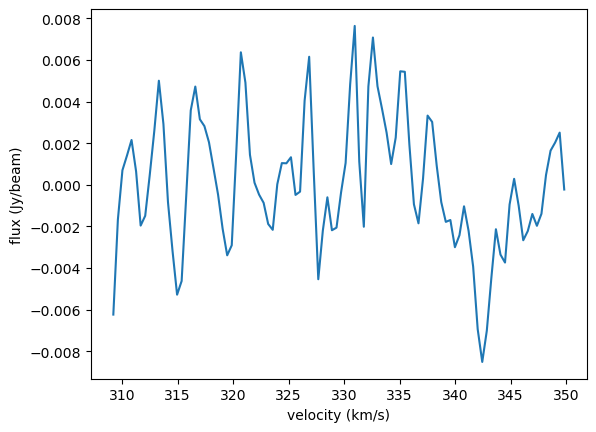

19


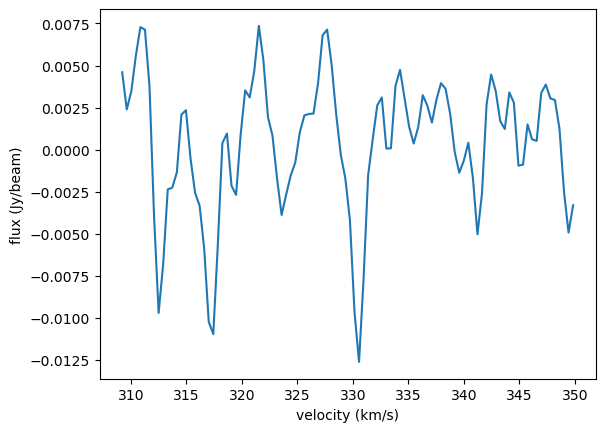

20


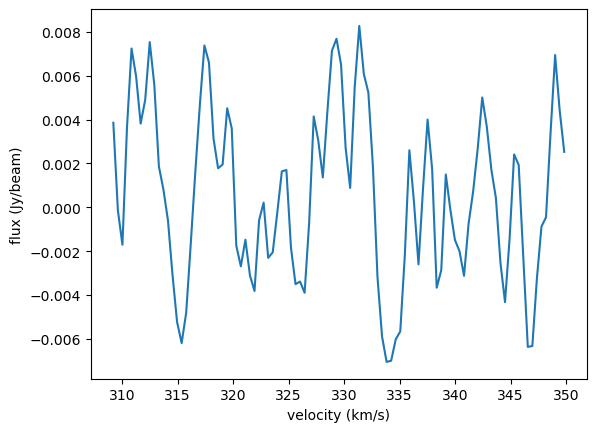

21


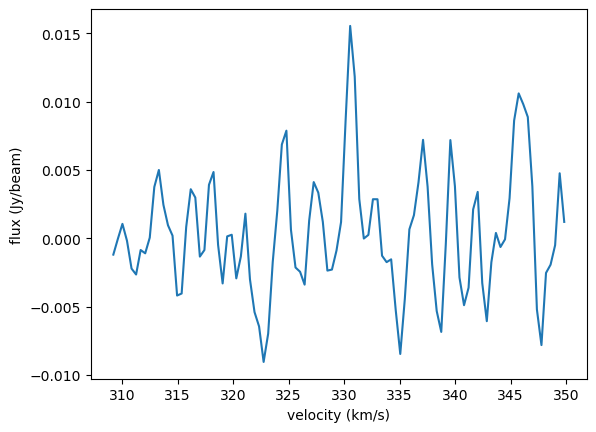

22


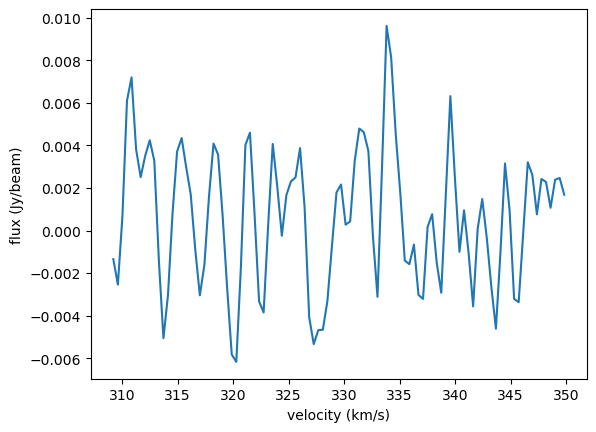

23


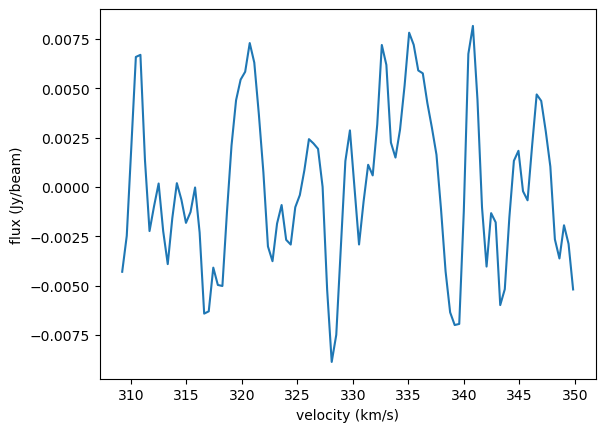

24


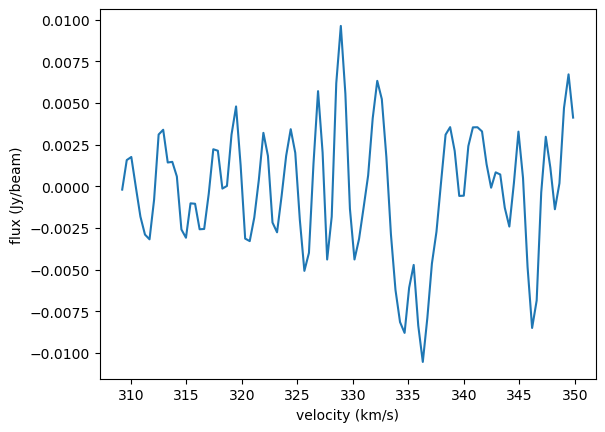

25


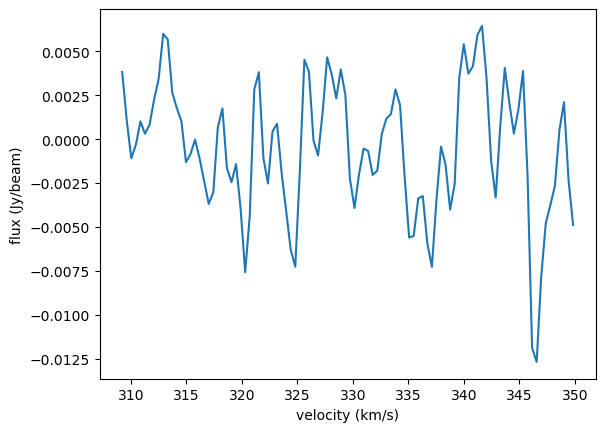

26


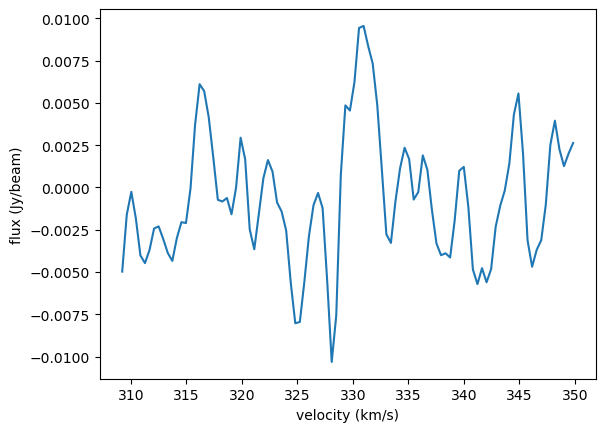

27


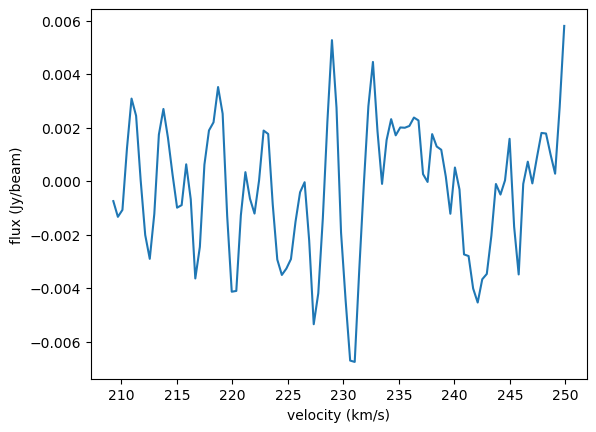

28


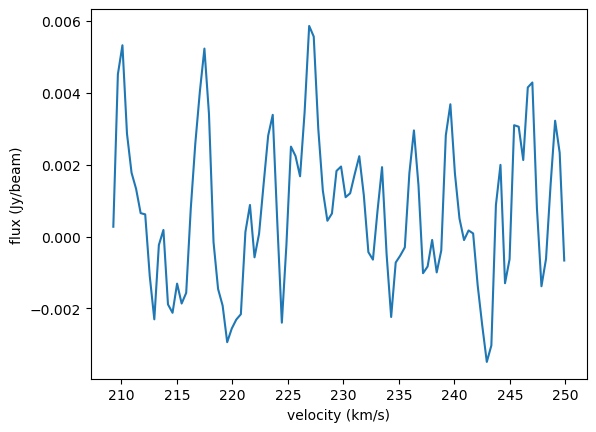

29


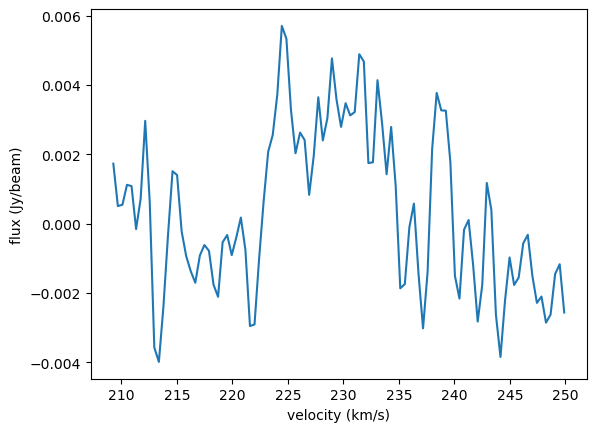

30


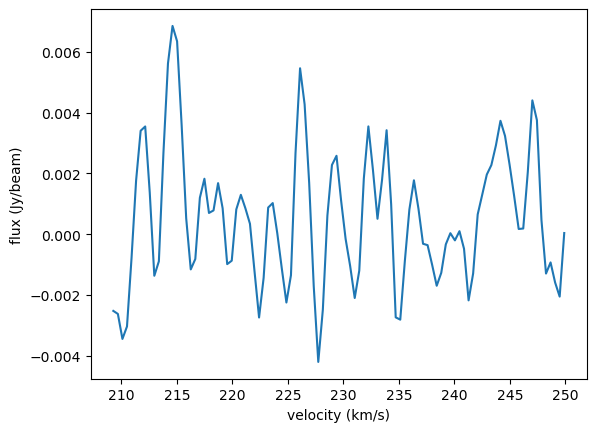

31


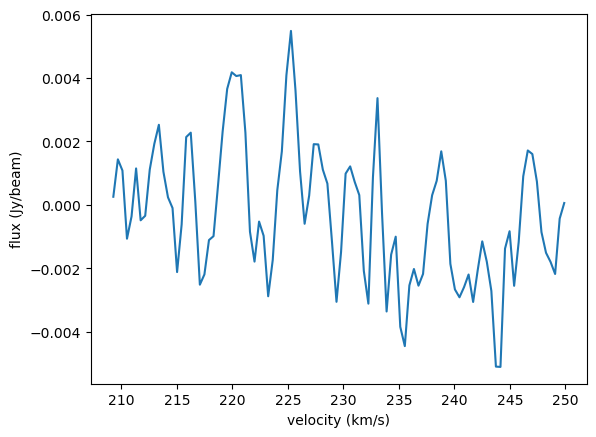

32


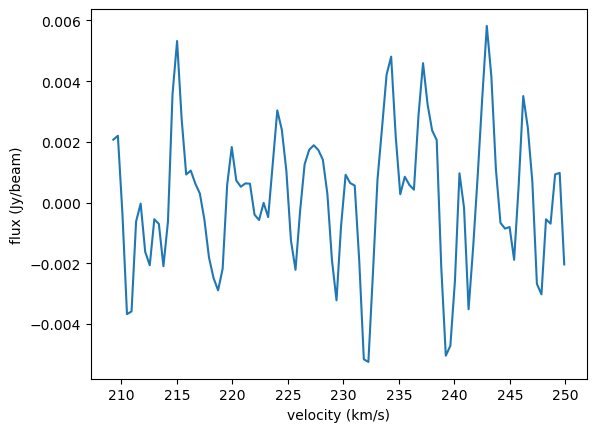

33


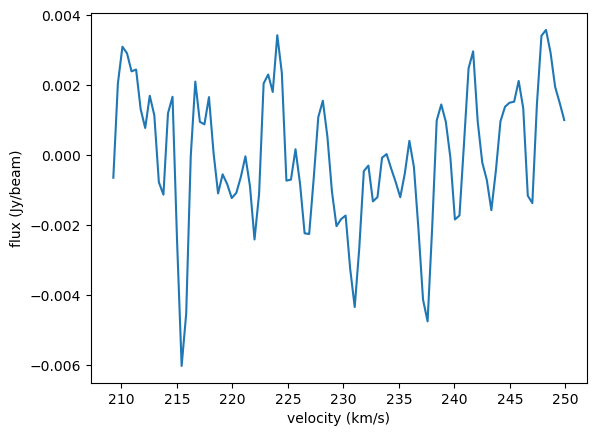

34


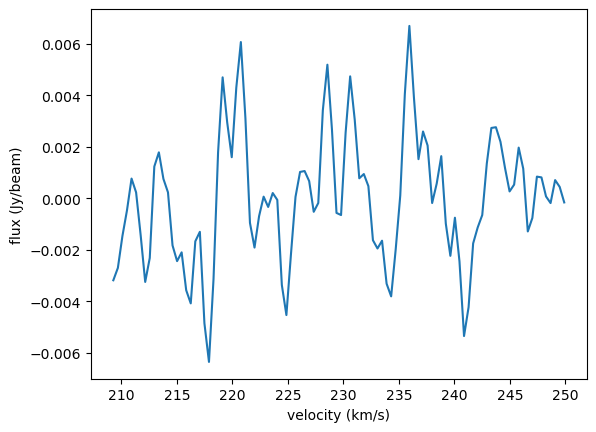

35


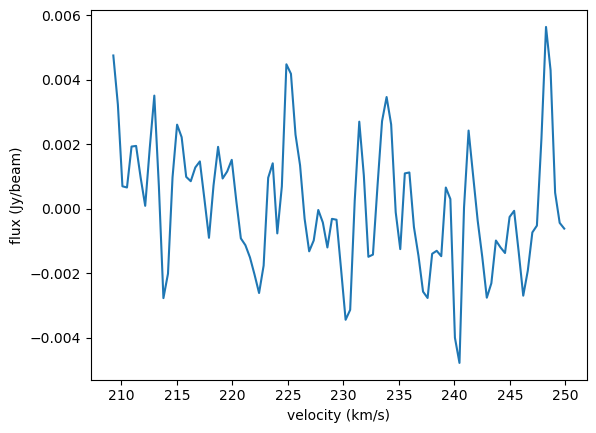

36


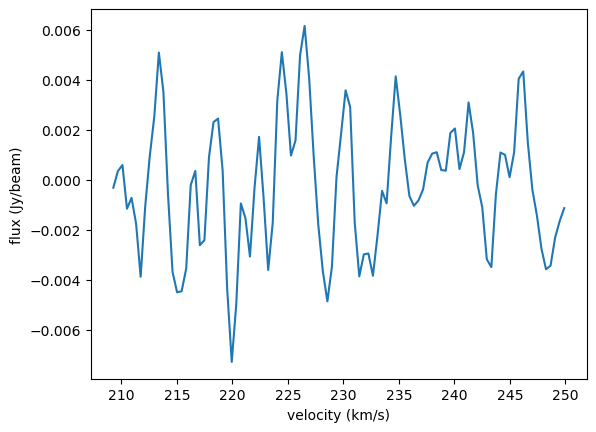

37
[0.003406014862090709, 0.004276413968032803, 0.003826596604047627, 0.003620638163540076, 0.003646219155687551, 0.004380765035025695, 0.003852017551706516, 0.0032026897350043077, 0.005111270618069422, 0.003678487224506193, 0.0034786375255723414, 0.003437285886893133, 0.003826240142264113, 0.003363110007408923, 0.0034335713388028892, 0.0035961533823008086, 0.0038023089151372836, 0.003421903546262649, 0.004298839845436247, 0.00317064244210872, 0.004056955670302466, 0.0038945223047567603, 0.004491515026792432, 0.003214362146273414, 0.0040047882252566185, 0.0037851705513271337, 0.0037319182796907145, 0.003830538391390555, 0.0024898261647117114, 0.0021090571596288376, 0.002328225779471824, 0.0022089010822305714, 0.0021423141665098734, 0.0023098035946139527, 0.0019216911094597144, 0.0025035750102097984, 0.0019892469397896004, 0.0026654400432088734]


In [12]:
# 计算每一条谱线噪声的σ
noise_list=[]
for i in range(len(data)):
    noise_y=noise_sigma(data[i],0)
    print(i)
    noise_level=np.std(noise_y)
    noise_list.append(noise_level)
print(noise_list)

In [13]:
def hebin(list_x,list_y):    # 把列表每三个数据合成一个
    list_x_new=[]
    list_y_new=[]
    for i in range(int(len(list_x)/3)):
        x0=list_x[3*i]
        x1=list_x[3*i+1]
        x2=list_x[3*i+2]
        y0=list_y[3*i]
        y1=list_y[3*i+1]
        y2=list_y[3*i+2]
        list_x_new.append((x0+x1+x2)/3)
        list_y_new.append((y0+y1+y2)/3)
    return list_x_new,list_y_new

In [14]:
def set_noise_to_zero(y,min_peak_height=0.1):
    """
    将噪声部分设为0，同时保留小峰。
    
    参数:
        x (np.array): 波长/横坐标数据。
        y (np.array): 强度/纵坐标数据。
        window_size (int): 局部窗口大小。
        threshold_multiplier (float): 阈值倍数（默认3σ）。
        min_peak_height (float): 小峰的最小高度。
    
    返回:
        tuple: (x, y_clean) 处理后的数据。
    """
    # 计算局部噪声阈值
    thresholds = noise_level*3
    
    # 使用峰值检测算法识别小峰
    peaks, _ = find_peaks(y, height=min_peak_height)
    
    
    # 创建掩码：保留高于阈值或属于小峰且非异常值的数据点
    mask = ((y > thresholds) | np.isin(np.arange(len(y)), peaks)) 
    
    # 将噪声部分设为0
    y_clean = np.where(mask, y, 0)
    
    return y_clean

In [15]:
# 归一化
def guiyihua(list5,noise):
    a_max=max(list5)
    list6=[]
    noise_nol=0
    for i in range(len(list5)):
        list6.append(list5[i]/a_max)
    noise_nol=(noise/a_max)
    return list6,noise_nol

In [16]:
# 放大谱线
def enlarge3(x,y):
    m=max(y)
    index_m=y.index(m)
    data_x=x[index_m-80:index_m+80]
    data_y=y[index_m-80:index_m+80]
    return data_x,data_y

In [17]:
# 找到每个源的视向速度
def Vsys(name,source,V):
    V_rest_source=[]
    for i in range(len(name)):
        for j in range (len(source)):
            if name[i]==source[j]:
                V_rest_source.append(V[j])
                break
    return V_rest_source
                

In [18]:
def duiqi_v(list_x,list_y):
    delta_x=0.42336   # 步长
    x_start=-40 
    x_finish=40
    num=int((x_finish-x_start)/delta_x)+1  # 对齐之后数据长度
    y_flux=[]   # 对齐横坐标之后，只需要记录纵坐标。这是纵坐标。
    find_x=[]
    find_y=[]
    find_x=copy.deepcopy(list_x)
    find_y=copy.deepcopy(list_y)
    #print(type(find_x))
    for i in range(num):
        a=x_start+i*delta_x
        b=x_start+(i+1)*delta_x
        #print("开始")
    # 找原横坐标对应区间(比如新x轴在【-26.4，-26】区间内的数据，就要找到原来x轴位于该区间的数据)
        if len(find_x)>=3:        # 原来x轴的数据还剩下3个以上
            data1_x=find_x[0]
            data2_x=find_x[1]
            data3_x=find_x[2]
            #print(data1_x)
            if data1_x>=a and data1_x<=b and data2_x>=b:
                y_flux.append(find_y[0])
                find_x.remove(data1_x)   # 把已经找到的数据删掉
                find_y.remove(find_y[0])
                #print("进入了第一种情况")
                continue
            elif data1_x>b:
                y_flux.append(0)
                #print("有0")
#                 print(n)
#                 print(data1_x,data2_x,data3_x)
#                 print(a,b)
                continue
            elif data1_x>=a and data2_x<=b and data3_x>b:
                y_flux.append((find_y[0]+find_y[1])/2)
                find_x.remove(data1_x)
                find_x.remove(data2_x)
                find_y.remove(find_y[0])
                find_y.remove(find_y[0])
                #print("进入了第三种情况")
                continue

        elif len(find_x)==2:         # 原来x轴的数据还剩下2个
            #print("还有2个数据！")
            data1_x=find_x[0]
            data2_x=find_x[1]
            if data1_x>=a and data1_x<=b and data2_x>=b:
                y_flux.append(find_y[0])
                find_x.remove(data1_x)   # 把已经找到的数据删掉
                find_y.remove(find_y[0])
                #print("进入了第一种情况")
                continue
            elif data1_x>b:
                y_flux.append(0)

                continue
            elif data1_x>=a and data2_x<=b:
                y_flux.append((find_y[0]+find_y[1])/2)
                find_x.remove(data1_x)
                find_x.remove(data2_x)
                find_y.remove(find_y[0])
                find_y.remove(find_y[0])
                #print("进入了第三种情况")
                continue

        elif len(find_x)==1:       # 原来x轴的数据还剩下1个
            #print("还有1个数据！")
            y_flux.append(find_y[0])
            find_x.remove(find_x[0])   # 把已经找到的数据删掉
            find_y.remove(find_y[0])
            continue

        elif len(find_x)==0:
            #print("没有数据了！")
            y_flux.append(0)
        

    #print(y_flux)
    #plt.plot(y_flux)
    return y_flux

In [19]:
# 去掉3σ外的数据（把噪声3σ下的删掉）（没有合并时）
def remove_3sigma3(list1,list2,noise):
    list3=copy.deepcopy(list2)
#     a=max(list2)
#     n_a=list2.index(a)
    # 检测峰及其突出度
    peaks, properties = find_peaks(list3, prominence=0.4)
    #print(peaks)
    left_peak=0
    right_peak=0
    if len(peaks) < 2:
        left_peak=list2.index(max(list2))
        right_peak=list2.index(max(list2))
        #print("只有一个峰:",len(peaks))
    else:
        # 根据突出度选择前两个主峰
        prominences = properties['prominences']
        peak_indices = sorted(zip(prominences, peaks), key=lambda x: -x[0])[:2]
        selected_peaks = sorted([pi[1] for pi in peak_indices])  # 按位置排序
        left_peak, right_peak = selected_peaks
        #print("有两个峰")
        
# # 把左边的降到0以外的都去掉
#     for i in range(left_peak-1,-1,-1):
#         if  list3[i]<=0:
#             #print("去除噪声（左边）")
#             for j in range(i+1):
#                 list3[j]=0
#             break
# # 把右边的降到0以外的都去掉
#     for i in range( right_peak,len(list3)):
#         if list3[i]<=0:
#             #print("去除噪声（右边）")
#             for j in range(i,len(list3)):
#                 list3[j]=0
#             break
            
# 从最大值开始往左边找
    for i in range(left_peak-1,-1,-1):
        if (list3[i]<noise*3 and list3[i-1]<noise*3 )or list3[i]<=0:
            #print("去除噪声（左边）")
            for j in range(i):
                list3[j]=0
            break
# 从最大值开始往右边找
    for i in range( right_peak,len(list3)):
        if (list3[i]<noise*3 and list3[i+1]<noise*3 )or list3[i]<=0 or list3[i+1]<=0 or list3[i+2]<=0:
            #print("去除噪声（右边）")
            for j in range(i,len(list3)):
                list3[j]=0
            break
    #print(left_peak, right_peak)

    return list3

In [20]:
V_rest_source=Vsys(name_list,sou,V)
print(V_rest_source)
print(len(V_rest_source))
print(len(data))

[238.1743317, 237.2864075, 265.6809082, 238.877655, 245.0176086, 238.6717224, 239.5157166, 237.3270874, 235.751358, 251.2273865, 287.328125, 265.0068359, 274.9273682, 231.8370972, 267.088623, 235.3066406, 283.1570435, 249.9293213, 276.4645691, 230.7684784, 296.7356262, 283.2704773, 236.2545319, 223.7095947, 245.5217133, 256.5096436, 273.8621216, 240.6420593, 165.10672, 110.6276779, 142.4628601, 162.0758209, 190.4225006, 153.1679382, 163.216629, 146.7512207, 132.2571564, 189.7614899]
38
38


In [21]:
# for i in range(len(data)):
#     x,y=data_to_xy(data[i])
#     x_large,y_large=enlarge3(x,y)
#     x_large=np.array(x_large)
#     x_large_real=x_large-V_rest_source[i]
#     a=x_large_real[0]
#     b=x_large_real[1]
#     #print(b-a)
#     paint(x_large_real,y_large)
#     #print(len(x_large))

In [22]:
#print(data_flux)

In [30]:
data_flux=[]
for i in range(len(data)):
    x,y=data_to_xy(data[i])
    x_large,y_large=enlarge3(x,y)
    x_large=np.array(x_large)
    x_large_real=x_large-V_rest_source[i]
    #a=x_large_real[0]
    #b=x_large_real[1]
    #print(b-a)
    #paint(x_large_real,y_large)
    copied_list_x = copy.deepcopy(x_large_real)
    x_large_real_1=copied_list_x[::-1]
    y_large_1=y_large[::-1]
    x_large_real_2=x_large_real_1.tolist()
    #print(type(x_large_real_2))
    y_flux=duiqi_v(x_large_real_2,y_large_1)
    
    y_flux_nol,noise_nol=guiyihua(y_flux,noise_list[i])  # 归一化
    y_flux_out_noise_nol=remove_3sigma3(x_large_real_2,y_flux_nol,noise_nol)  # 去掉噪声
    
#     #-------------论文插图---------------
#     if i==28:
#         plt.plot(y_flux_out_noise_nol)
#         plt.title("3σ discriminant")
#         plt.ylabel("Flux (Jy/beam)")
#         plt.savefig('C:/Users/zyx/Desktop/all-picture/3.2(a).png')
#         plt.show()
#     #------------------------------------
    
    data_flux.append(y_flux_out_noise_nol)
        
#     plt.plot(y_flux_nol)
#     plt.plot(y_flux_out_noise_nol)
        
#     plt.title(name_list[i])
#     #plt.savefig('./picture/HCO+/{}_nol.png'.format(name_list[i]))
#     plt.show()

In [31]:
from sklearn.datasets import load_digits
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE,MDS, Isomap,LocallyLinearEmbedding,SpectralEmbedding
from sklearn.decomposition import PCA

In [32]:
# print(len(data_flux))
# for i in range(len(data_flux)):
#     print(len(data_flux[i]))
#     if len(data_flux[i])==0:
#         print("空白列表是：",i)

In [76]:
tsne=TSNE(random_state=42)
mds=MDS(n_components=2)
#iso=Isomap(n_components=2,n_neighbors=30)
#local=LocallyLinearEmbedding(n_components=2)
spec=SpectralEmbedding(n_components=3)

# digits_tsne=tsne.fit_transform(data_flux)
# digits_mds=mds.fit_transform(data_flux)
# digits_iso=iso.fit_transform(data_flux)
# digits_local=local.fit_transform(data_flux)
digits_spec=spec.fit_transform(data_flux)


# # t-SNE
# for i in range(len(digits_tsne)):
#     color=cmap(i / len(digits_tsne))
#     plt.scatter(digits_tsne[i, 0], digits_tsne[i, 1], color=color, label=name_list[i])

# plt.legend()
# plt.xlabel('t-SNE feature 0')
# plt.ylabel('t-SNE feature 1')
# plt.savefig('./picture/t-SNE.png')
# plt.show()

# # MDS
# plt.figure(figsize=(20,20))
# # plt.xlim(digits_mds[:,0].min(),digits_mds[:,0].max()+1)
# # plt.ylim(digits_mds[:,1].min(),digits_mds[:,1].max()+1)
# for i in range(len(digits_mds)):
# #     plt.text(digits_mds[i,0],digits_mds[i,1],str(new_name[i]),
# #              color=colors[i],
# #              fontdict={'weight':'bold','size':15})
#     color=cmap(i / len(digits_mds))
#     plt.scatter(digits_mds[i, 0], digits_mds[i, 1], color=color, label=name_list[i])
# # new_texts = [plt.text(x_, y_, text, fontsize=12) for x_, y_, text in zip(digits_mds[:, 0], digits_mds[:, 1], name_list)]
# # adjust_text(new_texts,arrowprops=dict(arrowstyle='->',color='red',lw=1))
# # plt.ylim(-1,1)
# # plt.xlim(-1,1)
# plt.legend()
# plt.savefig('./picture/MDS.png')
# plt.show()



D:\anaconda\lib\site-packages\sklearn\manifold\_spectral_embedding.py:274: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [77]:
# 获取模型的相似度矩阵（需访问内部变量，此处为示例）
# 注意：SpectralEmbedding 未直接暴露邻接矩阵，需手动构建
from sklearn.neighbors import kneighbors_graph

# 构建邻接矩阵（K近邻图）
W = kneighbors_graph(data_flux, n_neighbors=5, mode='connectivity', include_self=True).toarray()

# 对称化邻接矩阵（确保对称性）
W = 0.5 * (W + W.T)

# 计算度矩阵和拉普拉斯矩阵
D = np.diag(W.sum(axis=1))
L = D - W

# 计算特征值
eigenvalues, eigenvectors = np.linalg.eigh(L)

# 提取最小的非零特征值（前两个）
sorted_indices = np.argsort(eigenvalues)
eigenvalues_sorted = eigenvalues[sorted_indices]
eigenvectors_sorted = eigenvectors[:, sorted_indices]

# 输出前5个最小的特征值
print(eigenvalues_sorted)
print(eigenvectors_sorted[0])

[-2.02873592e-15  9.49020679e-02  4.90263715e-01  6.97791124e-01
  1.27597124e+00  1.49156025e+00  1.51491481e+00  1.78389612e+00
  2.17267751e+00  2.17996300e+00  2.48314383e+00  2.58587362e+00
  2.75693611e+00  3.00679466e+00  3.14614228e+00  3.27639847e+00
  3.50000000e+00  3.56874272e+00  3.65559977e+00  4.30702000e+00
  4.38008768e+00  4.68166492e+00  4.92429441e+00  4.96959955e+00
  5.13852593e+00  5.43619289e+00  5.59048324e+00  5.66300737e+00
  5.72764780e+00  5.97741114e+00  6.00000000e+00  6.11122426e+00
  6.11789148e+00  6.73346494e+00  7.06658321e+00  7.72538297e+00
  7.77796438e+00  7.98998253e+00]
[-0.16222142  0.12882579 -0.06618284  0.18184624  0.00097436 -0.06738384
 -0.03503554  0.07307727 -0.07414395 -0.03986002  0.14048766  0.03002841
  0.01765669  0.00806052 -0.06909696 -0.0201723   0.         -0.02468124
  0.04139049  0.01734401  0.1734363  -0.05962744 -0.09650583  0.11770718
  0.00590431  0.06917353 -0.00147391 -0.08238564  0.30525676  0.00418031
  0.          0.

In [78]:
# 读取每个源的光度
import pandas as pd

# 假设文件格式：
# 列名: ID   Vsys   RA    Dec
# 数据: 001  250.3  12.5  30.0
# 注释行以 '#' 开头

df_L = pd.read_csv(
    "C:\\Users\\zyx\\Desktop\\data\\name_L.txt",
    sep='\s+',          # 按空格/制表符分隔
    #comment='#',        # 忽略注释行
    header=0,           # 第一行为列名
    #names=['ID', 'Vsys', 'RA', 'Dec']  # 可选：手动指定列名
)

#print(df_L.iloc[:, 0].tolist())   # df.head()则默认输出前五行数据，在数据量大的时候可以方便检查

name_=df_L.iloc[:, 0].tolist()
name_L=df_L.iloc[:, 1].tolist()
name_.pop(1)   # Ll02和Ll04删掉
name_L.pop(1)
name_.pop(2)
name_L.pop(2)
print(name_)
print(name_L)

['Ll01', 'Ll03', 'Ll05', 'Ll06', 'Ll07', 'Ll08', 'Ll09', 'Ll10', 'Lm01', 'Lm02', 'Lm03', 'Lm04', 'Lm05', 'Lm06', 'Lm07', 'Lm08', 'Lm09', 'Lm10', 'Lh01', 'Lh02', 'Lh03', 'Lh04', 'Lh05', 'Lh06', 'Lh07', 'Lh08', 'Lh09', 'Lh10', 'S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10']
[1.08, 1.13, 1.48, 1.9, 1.93, 2.8, 2.81, 2.82, 3.25, 3.52, 3.53, 3.68, 4.21, 4.58, 6.18, 7.76, 7.96, 8.3, 10.3, 11.3, 11.6, 12.7, 14.7, 15.3, 15.5, 16.5, 20.8, 23.1, 1.0, 1.6, 1.9, 2.2, 2.3, 2.6, 2.8, 3.3, 6.1, 14.0]


In [79]:
print(digits_spec[0])

[-0.06140221 -0.0418371   0.06462652]


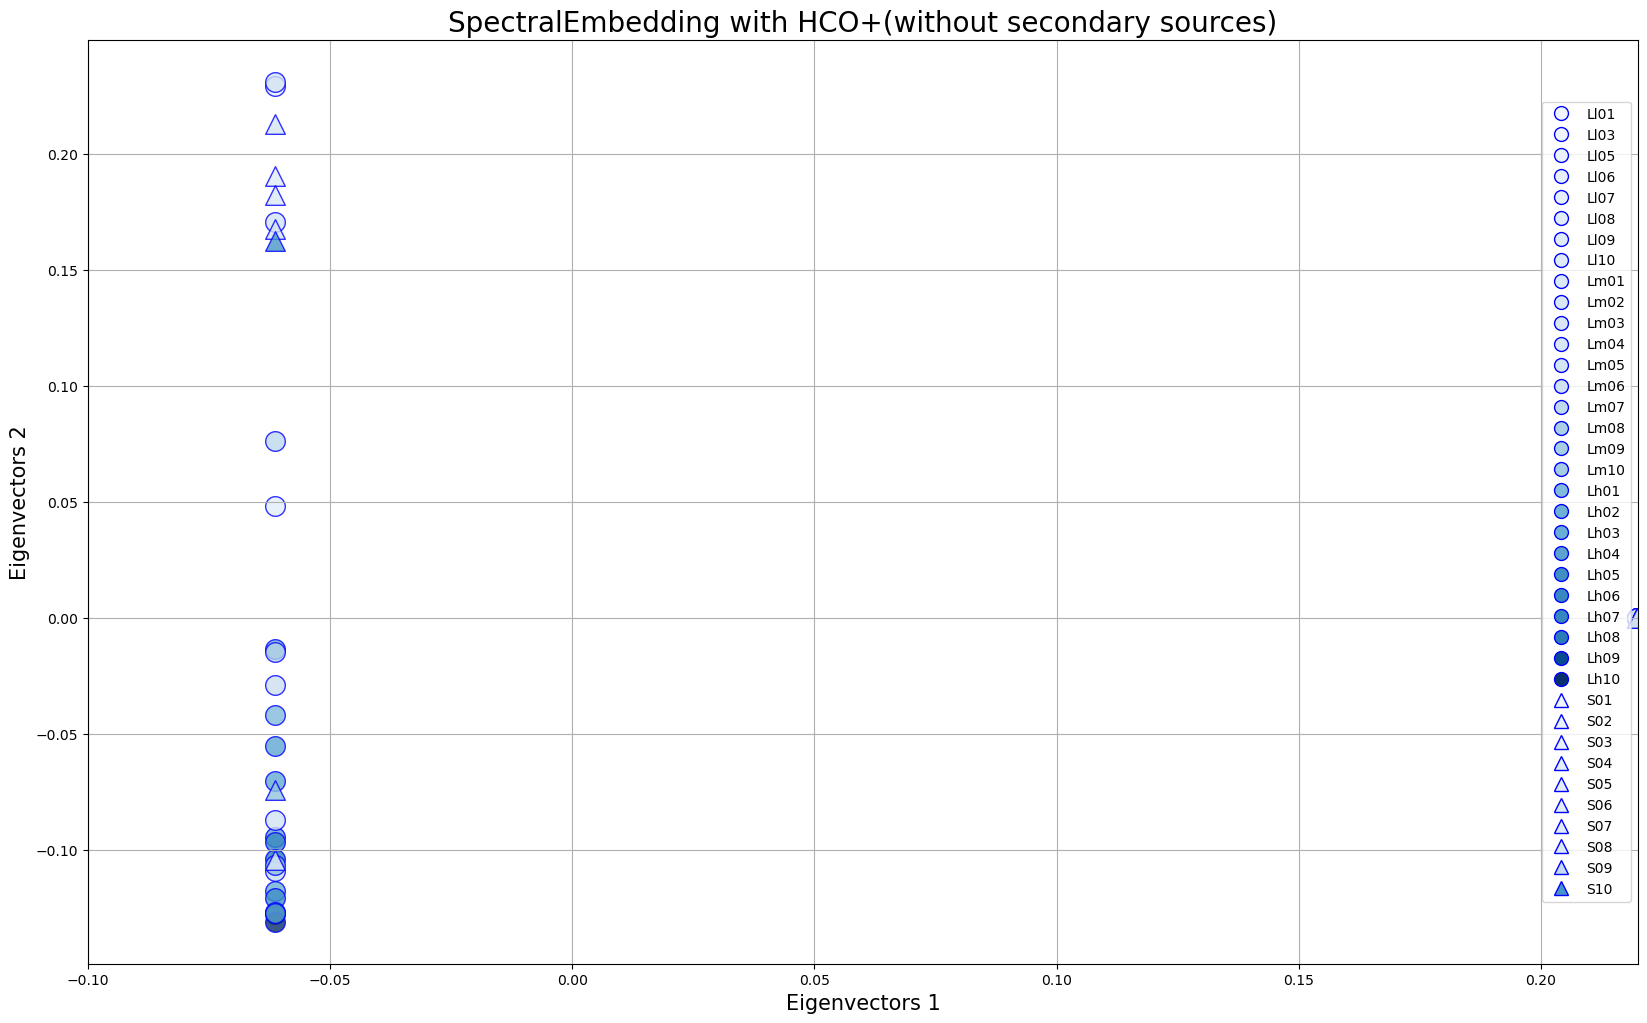

In [80]:
# 画图
# SpectralEmbedding
plt.figure(figsize=(20,12))
plt.grid()
plt.xlim(-0.1,0.22)

# 颜色设置
cmap1=plt.cm.Blues
cmap2=plt.cm.Oranges
cmap3=plt.cm.Purples
cmap4=plt.cm.Greens

spec_marker=[]
# digits_str = name_list[0][2:4]
# print(digits_str)
# print(int(digits_str))

for i in range(len(digits_spec)):
    if name_list[i][0]=="L":    # 大麦哲伦云里的
        spec_marker.append("o")
        for j in range(len(name_)):
            if name_list[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                    plt.scatter(digits_spec[i, 0], digits_spec[i, 1], s=200,color=color0, label=name_list[i],alpha=0.8,edgecolors='blue')
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                    plt.scatter(digits_spec[i, 0], digits_spec[i, 1], s=200,color=color0, label=name_list[i],alpha=0.8,edgecolors='blue')
                    break
        continue
        
    elif name_list[i][0]=="S":
        spec_marker.append("^")
        for j in range(len(name_)):
            if name_list[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                    plt.scatter(digits_spec[i, 0], digits_spec[i, 1], s=200,color=color0, label=name_list[i],alpha=0.8,marker="^",edgecolors='blue')
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                    plt.scatter(digits_spec[i, 0], digits_spec[i, 1], s=200,color=color0, label=name_list[i],alpha=0.8,marker="^",edgecolors='blue')
                    break
        continue

    
# new_texts = [plt.text(x_, y_, text, fontsize=12) for x_, y_, text in zip(digits_spec[:, 1], digits_spec[:, 2], name_list)]
# adjust_text(new_texts,arrowprops=dict(arrowstyle='->',color='red',lw=1))

# 把按顺序的光度转换为颜色
color=[]
for i in range(len(name_L)):
    if name_L[j]>=10:
        color.append(cmap1( name_L[i]/max(name_L)))
    elif name_L[j]<10:
        color.append(cmap1( name_L[j]/15))

# 使用循环生成句柄列表
handles = []
for cat, color, marker in zip(name_, color, spec_marker):
    handle = Line2D(
        [], [], 
        color=color, 
        marker=marker, 
        linestyle="None",  # 无连线
        markersize=10, 
        label=cat,
        markeredgecolor="blue"
    )
    handles.append(handle)
    
plt.legend(handles=handles, loc="center right")
plt.title("SpectralEmbedding with HCO+(without secondary sources)",fontsize=20)
plt.xlabel("Eigenvectors 1",fontsize=15)
plt.ylabel("Eigenvectors 2",fontsize=15)
plt.savefig('./picture/SpectralEmbedding_out_(Blues)(HCO+).png')
plt.show()

In [56]:
def add_jitter_to_duplicates(x, y, jitter_scale):
    # 转换为numpy数组以便使用高级索引
    x = np.asarray(x)
    y = np.asarray(y)
    
    # 检测重合点
    points = list(zip(x, y))
    duplicate_dict = {}
    
    for i, (xi, yi) in enumerate(points):
        duplicate_dict.setdefault((xi, yi), []).append(i)
 
    # 生成抖动偏移量
    xj = x.copy()
    yj = y.copy()
    
    for (xi, yi), indices in duplicate_dict.items():
        if len(indices) > 1:
            # 使用numpy的高级索引
            theta = np.linspace(0, 2*np.pi, len(indices), endpoint=False)
            r = np.random.normal(0, jitter_scale, len(indices))
            
            dx = r * np.cos(theta)
            dy = r * np.sin(theta)
            
            # 通过numpy索引直接赋值
            xj[indices] += dx
            yj[indices] += dy
            
    return xj, yj

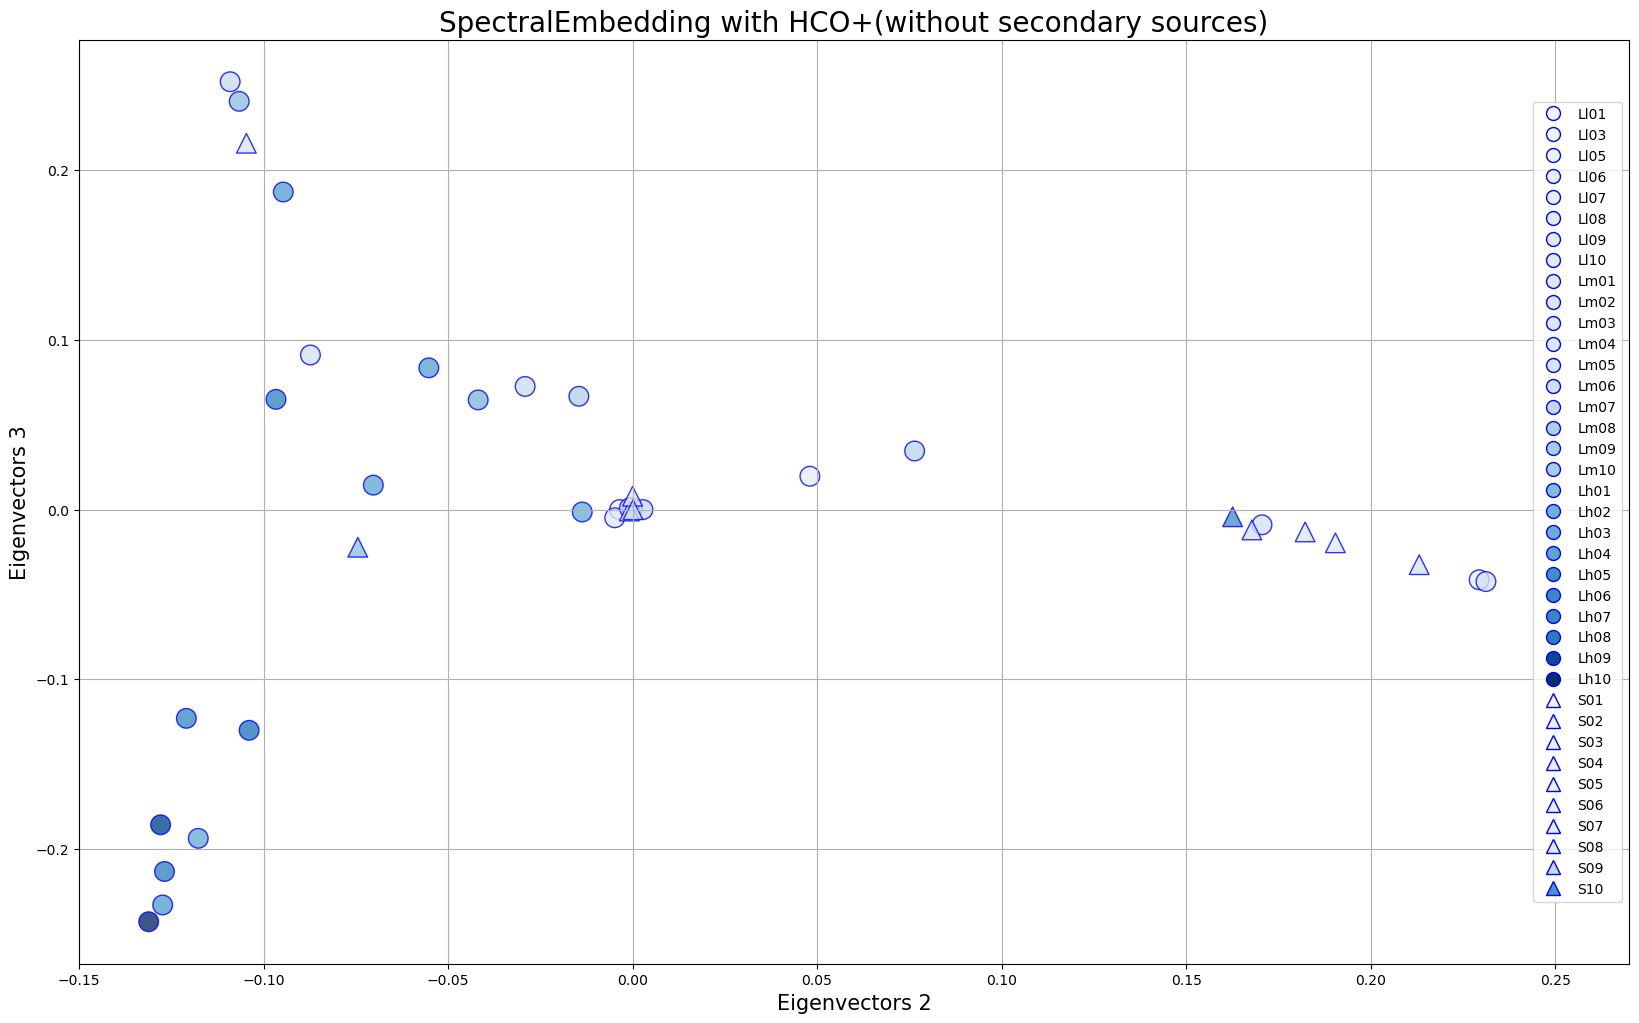

In [61]:
# 画图
# SpectralEmbedding
plt.figure(figsize=(20,12))
plt.grid()
plt.xlim(-0.15,0.27)

# 颜色设置
cmap1=plt.cm.Blues
cmap2=plt.cm.Oranges
cmap3=plt.cm.Purples
cmap4=plt.cm.Greens

spec_x=[]
spec_y=[]
spec_color=[]
spec_name=[]
spec_marker=[]

for i in range(len(digits_spec)):
    if name_list[i][0]=="L":    # 大麦哲伦云里的
        for j in range(len(name_)):
            if name_list[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                # 0附近的点直接记为0
                    if abs(digits_spec[i,1])<1e-10:
                        spec_x.append(0)
                    else:
                        spec_x.append(digits_spec[i,1])
                # 0附近的点直接记为0
                    if abs(digits_spec[i,2])<1e-10:
                        spec_y.append(0)
                    else :
                        spec_y.append(digits_spec[i,2])
                    spec_color.append(color0)
                    spec_name.append(name_list[i])
                    spec_marker.append("o")
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                # 0附近的点直接记为0
                    if abs(digits_spec[i,1])<1e-10:
                        spec_x.append(0)
                    else:
                        spec_x.append(digits_spec[i,1])
                # 0附近的点直接记为0
                    if abs(digits_spec[i,2])<1e-10:
                        spec_y.append(0)
                    else :
                        spec_y.append(digits_spec[i,2])
                    spec_color.append(color0)
                    spec_name.append(name_list[i])
                    spec_marker.append("o")
                    break
        continue
        
    elif name_list[i][0]=="S":
        for j in range(len(name_)):
            if name_list[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                # 0附近的点直接记为0
                    if abs(digits_spec[i,1])<1e-10:
                        spec_x.append(0)
                    else:
                        spec_x.append(digits_spec[i,1])
                # 0附近的点直接记为0
                    if abs(digits_spec[i,2])<1e-10:
                        spec_y.append(0)
                    else :
                        spec_y.append(digits_spec[i,2])
                        
                    spec_color.append(color0)
                    spec_name.append(name_list[i])
                    spec_marker.append("^")
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                # 0附近的点直接记为0
                    if abs(digits_spec[i,1])<1e-10:
                        spec_x.append(0)
                    else:
                        spec_x.append(digits_spec[i,1])
                # 0附近的点直接记为0
                    if abs(digits_spec[i,2])<1e-10:
                        spec_y.append(0)
                    else :
                        spec_y.append(digits_spec[i,2])
                        
                    spec_color.append(color0)
                    spec_name.append(name_list[i])
                    spec_marker.append("^")
                    break
        continue
spec_marker=np.array(spec_marker)
spec_color=np.array(spec_color)
spec_name=np.array(spec_name)
spec_xj, spec_yj = add_jitter_to_duplicates(spec_x, spec_y, jitter_scale=0.005)
mask_circle = (spec_marker == "o")
mask_triangle = (spec_marker == "^")
plt.scatter(spec_xj[mask_circle], spec_yj[mask_circle], s=200,color=spec_color[mask_circle],alpha=0.8,edgecolors='blue',label=spec_name[mask_circle])
plt.scatter(spec_xj[mask_triangle], spec_yj[mask_triangle], s=200,color=spec_color[mask_triangle],alpha=0.8,edgecolors='blue',marker="^",label=spec_name[mask_triangle])
# new_texts = [plt.text(x_, y_, text, fontsize=12) for x_, y_, text in zip(digits_spec[:, 1], digits_spec[:, 2], name_list)]
# adjust_text(new_texts,arrowprops=dict(arrowstyle='->',color='red',lw=1))

# 把按顺序的光度转换为颜色
color=[]
for i in range(len(name_L)):
    if name_L[j]>=10:
        color.append(cmap1( name_L[i]/max(name_L)))
    elif name_L[j]<10:
        color.append(cmap1( name_L[j]/15))

# 使用循环生成句柄列表
handles = []
for cat, color, marker in zip(name_, color, spec_marker):
    handle = Line2D(
        [], [], 
        color=color, 
        marker=marker, 
        linestyle="None",  # 无连线
        markersize=10, 
        label=cat,
        markeredgecolor="blue"
    )
    handles.append(handle)
    
plt.legend(handles=handles, loc="center right")
plt.title("SpectralEmbedding with HCO+(without secondary sources)",fontsize=20)
plt.xlabel("Eigenvectors 2",fontsize=15)
plt.ylabel("Eigenvectors 3",fontsize=15)
plt.savefig('./picture/SpectralEmbedding_out_(Blues)(HCO+)(2,3D).png')
plt.show()
#print(spec_color[mask_circle])

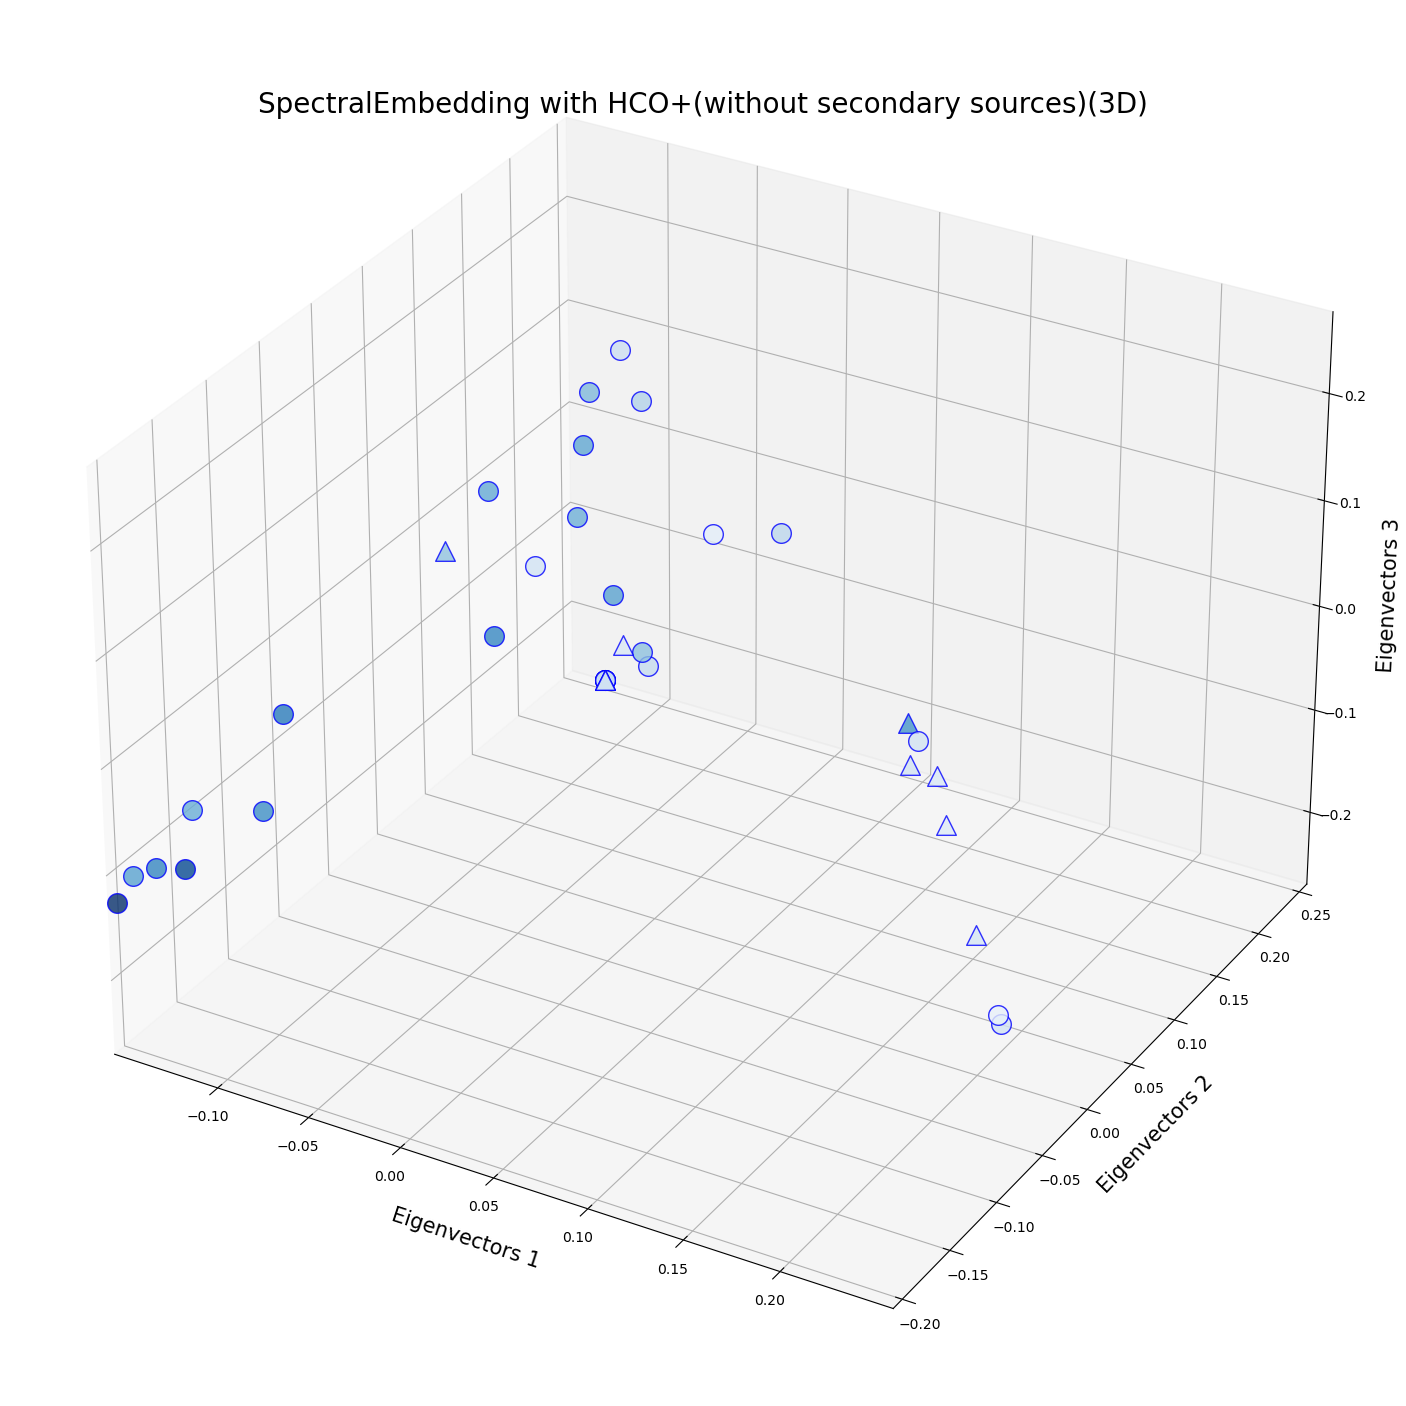

In [71]:
# 画图
# SpectralEmbedding
plt.figure(figsize=(18,18))


# 颜色设置
cmap1=plt.cm.Blues
cmap2=plt.cm.Oranges
cmap3=plt.cm.Purples
cmap4=plt.cm.Greens

ax1 = plt.axes(projection='3d')

# digits_str = name_list[0][2:4]
# print(digits_str)
# print(int(digits_str))

for i in range(len(digits_spec)):
    if name_list[i][0]=="L":    # 大麦哲伦云里的
        for j in range(len(name_)):
            if name_list[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                    ax1.scatter3D(digits_spec[i, 1], digits_spec[i, 2],digits_spec[i, 3], s=200,color=color0, label=name_list[i],alpha=0.8,edgecolors=(0,0,1,0.8))
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                    ax1.scatter3D(digits_spec[i, 1], digits_spec[i, 2],digits_spec[i, 3], s=200,color=color0, label=name_list[i],alpha=0.8,edgecolors=(0,0,1,0.8))
                    break
        continue
        
    elif name_list[i][0]=="S":
        for j in range(len(name_)):
            if name_list[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                    ax1.scatter3D(digits_spec[i, 1], digits_spec[i, 2],digits_spec[i, 3], s=200,color=color0, label=name_list[i],alpha=0.8,marker="^",edgecolors=(0,0,1,0.8))
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                    ax1.scatter3D(digits_spec[i, 1], digits_spec[i, 2],digits_spec[i, 3], s=200,color=color0, label=name_list[i],alpha=0.8,marker="^",edgecolors=(0,0,1,0.8))
                    break
        continue

ax1.set_ylim([-0.2, 0.25])
plt.title("SpectralEmbedding with HCO+(without secondary sources)(3D)",fontsize=20,y=1)
ax1.set_xlabel("Eigenvectors 1",fontsize=15,labelpad=10)
ax1.set_ylabel("Eigenvectors 2",fontsize=15,labelpad=10)
ax1.set_zlabel("Eigenvectors 3",fontsize=15,labelpad=10)

# new_texts = [plt.text(x_, y_, text, fontsize=12) for x_, y_, text in zip(digits_spec[:, 0], digits_spec[:, 1], data_name)]
# adjust_text(new_texts,arrowprops=dict(arrowstyle='->',color='red',lw=1))
#plt.legend(loc="right")
#plt.savefig('./picture/SpectralEmbedding(Blues)(HCO+out)(38).png')
plt.show()

['Lh01', 'Lh01_2', 'Lh01_3', 'Lh02', 'Lh02_2', 'Lh02_3', 'Lh03', 'Lh04', 'Lh05', 'Lh05_2', 'Lh05_3', 'Lh05_4', 'Lh06', 'Lh07', 'Lh08', 'Lh08_2', 'Lh08_3', 'Lh08_4', 'Lh09', 'Lh10', 'Ll01', 'Ll03', 'Ll04_2', 'Ll05', 'Ll06', 'Ll06_2', 'Ll06_3', 'Ll07', 'Ll07_2', 'Ll08', 'Ll09', 'Ll09_2', 'Ll09_3', 'Ll09_4', 'Ll09_5', 'Ll10', 'Lm01', 'Lm02', 'Lm02_2', 'Lm02_3', 'Lm03', 'Lm04', 'Lm04_2', 'Lm04_3', 'Lm05', 'Lm05_2', 'Lm05_3', 'Lm06', 'Lm06_2', 'Lm06_3', 'Lm07', 'Lm07_2', 'Lm07_3', 'Lm08', 'Lm09', 'Lm10', 'S01', 'S01_2', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S10_2']


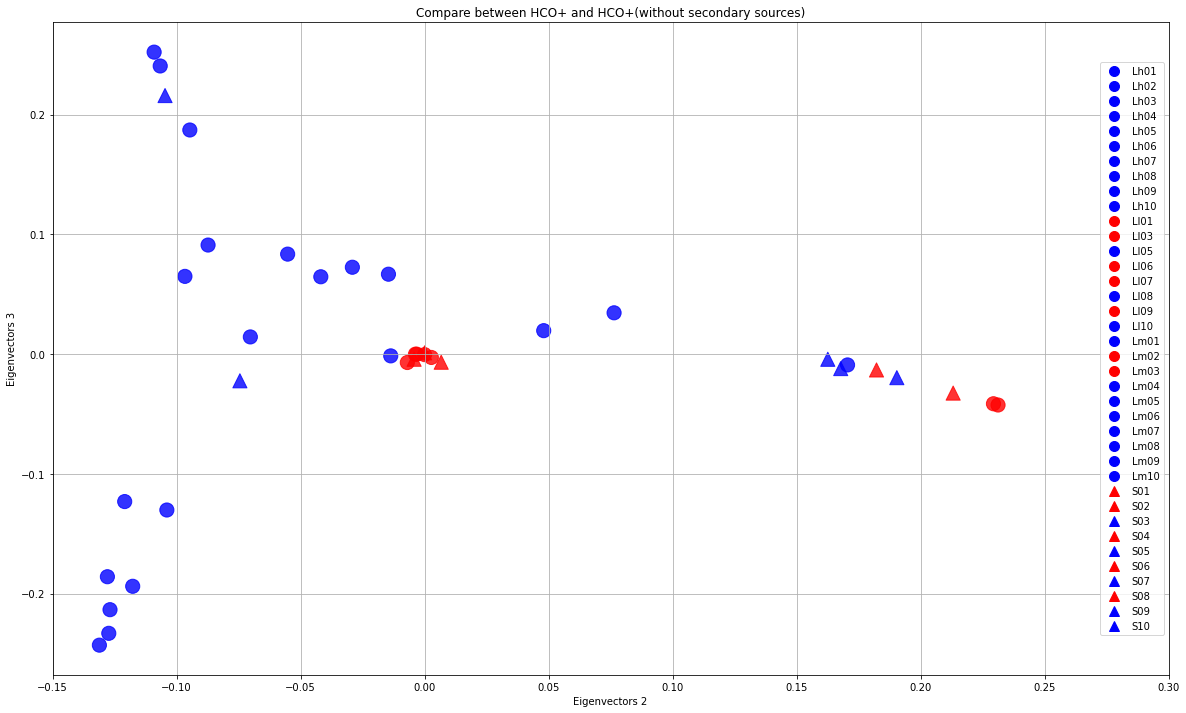

In [41]:
# 与不同的噪声处理方法的结果进行比较
file_path_color = "data_with_colors(HCO+)(3_sigma).txt"

# 假设文件格式：
# 列名: ID   Vsys   RA    Dec
# 数据: 001  250.3  12.5  30.0
# 注释行以 '#' 开头

df_noise = pd.read_csv(
    file_path_color,
    sep='\s+',          # 按空格/制表符分隔
    #comment='#',        # 忽略注释行
    header=0,           # 第一行为列名
    #names=['ID', 'Vsys', 'RA', 'Dec']  # 可选：手动指定列名
)

# print(df_color) 
nam=df_noise["name"].tolist()
colo=df_noise["color"].tolist()
print(nam)
# print(col)
fig, ax = plt.subplots(figsize=(20,12))
plt.grid()
ax.set_xlim(-0.15,0.30)
color0=[]
for i in range(len(digits_spec)):
    for j in range(len(nam)):
        if name_list[i]==nam[j]:
            color0.append(colo[j])
#             #print(color0)
#             ax.scatter(digits_spec[i, 1], digits_spec[i, 2],color=color0,s=50, label=name_list[i])
            break
    
       # plt.scatter(digits_spec[i, 0], digits_spec[i, 1],color="black", label=name_list[i])
color0=np.array(color0)
plt.scatter(spec_xj[mask_circle], spec_yj[mask_circle], s=200,color=color0[mask_circle],alpha=0.8)
plt.scatter(spec_xj[mask_triangle], spec_yj[mask_triangle], s=200,color=color0[mask_triangle],alpha=0.8,marker="^")
            
# new_texts = [plt.text(x_, y_, text, fontsize=12) for x_, y_, text in zip(digits_spec[:, 0], digits_spec[:, 1], name_list)]
# adjust_text(new_texts,arrowprops=dict(arrowstyle='->',color='red',lw=1))

# 使用循环生成句柄列表
handles = []
for cat, color, marker in zip(name_list, color0, spec_marker):
    handle = Line2D(
        [], [], 
        color=color, 
        marker=marker, 
        linestyle="None",  # 无连线
        markersize=10, 
        label=cat,
    )
    handles.append(handle)

# # 加载小图片
# image = Image.open('C:\\Users\\zyx\\Desktop\\毕设\\machine learning spectrum\\picture\\CO_compare_out_.png')  # 替换为你的图片路径
# image = np.array(image)  # 将图片转换为 NumPy 数组


# # 创建子区域（小图）
# inset_ax = inset_axes(ax, width=3, height=3, loc='lower right')  # 调整 width 和 height 控制大小
# inset_ax.imshow(image)
# inset_ax.axis('off')  # 隐藏坐标轴
plt.legend(handles=handles, loc="center right")
plt.title("Compare between HCO+ and HCO+(without secondary sources)")
plt.xlabel("Eigenvectors 2")
plt.ylabel("Eigenvectors 3")
plt.savefig('./picture/SpectralEmbedding_out_(Blues)(HCO+)(compare).png')
plt.show()

In [63]:
import pandas as pd

# 假设文件格式：
# 列名: ID   Vsys   RA    Dec
# 数据: 001  250.3  12.5  30.0
# 注释行以 '#' 开头

df_outflow = pd.read_csv(
    "C:\\Users\\zyx\\Desktop\\data\\all_outflow.txt",
    sep='\s+',          # 按空格/制表符分隔
    #comment='#',        # 忽略注释行
    header=0,           # 第一行为列名
    #names=['ID', 'Vsys', 'RA', 'Dec']  # 可选：手动指定列名
)

ccc=df_outflow.iloc[:, 0].tolist()   # df.head()则默认输出前五行数据，在数据量大的时候可以方便检查
name_outflow=[]
print(len(ccc))
for i in range(len(ccc)):
    if i*4<len(ccc):
        ddd=ccc[i*4][1::]
        name_outflow.append(ddd)
    else:
        break
print(name_outflow)
print(len(name_outflow))

148
['Ll01', 'Ll03', 'Ll05', 'Ll06', 'Ll07', 'Ll08', 'Ll09', 'Ll10', 'Lm01', 'Lm02', 'Lm04', 'Lm05', 'Lm07', 'Lm08', 'Lm09', 'Lm10', 'Lh01_1', 'Lh01_2', 'Lh02', 'Lh03', 'Lh04', 'Lh05_1', 'Lh05_2', 'Lh06', 'Lh07', 'Lh08', 'Lh09', 'Lh10', 'S01', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10']
37


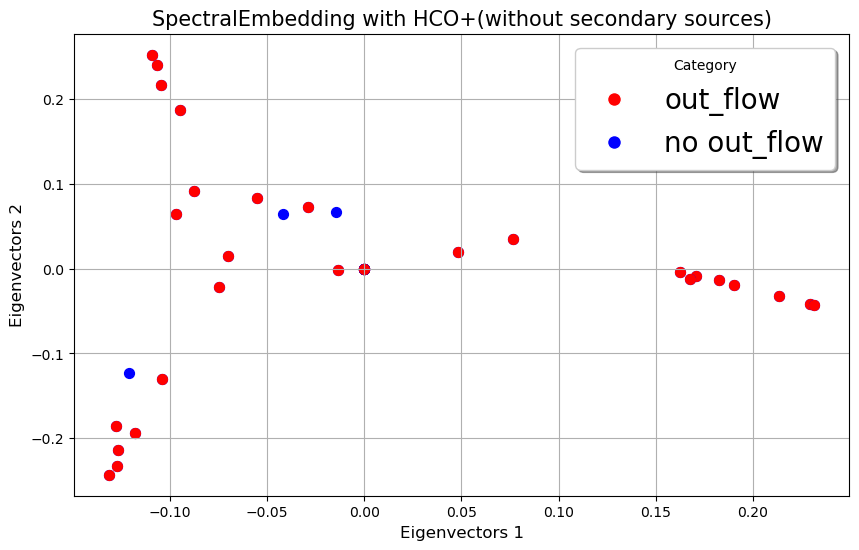

In [65]:
fig, ax = plt.subplots(figsize=(10,6))
ax.grid()
for i in range(len(digits_spec)):
    ax.scatter(digits_spec[i, 1], digits_spec[i, 2],color="Blue",s=50, label=name_list[i])
    for j in range(len(name_outflow)):
        if name_list[i]==name_outflow[j]:
            color0="Red"
            #print(color0)
            ax.scatter(digits_spec[i, 1], digits_spec[i, 2],color=color0,s=50, label=name_list[i])
            break
            
# 手动创建图例条目
legend_elements = [
    plt.Line2D([], [], marker='o', color='w', markerfacecolor='red', markersize=10, label='out_flow'),
    plt.Line2D([], [], marker='o', color='w', markerfacecolor='blue', markersize=10, label='no out_flow')
]

# 添加自定义图例
plt.legend(handles=legend_elements, title="Category", fontsize=20,frameon=True,shadow=True,)
#ax.legend(loc=1,ncol=2)
plt.title("SpectralEmbedding with HCO+(without secondary sources)",fontsize=15)
plt.xlabel("Eigenvectors 1",fontsize=12)
plt.ylabel("Eigenvectors 2",fontsize=12)
#plt.savefig('C:/Users/zyx/Desktop/all-picture/4.23(b).png')
plt.show()

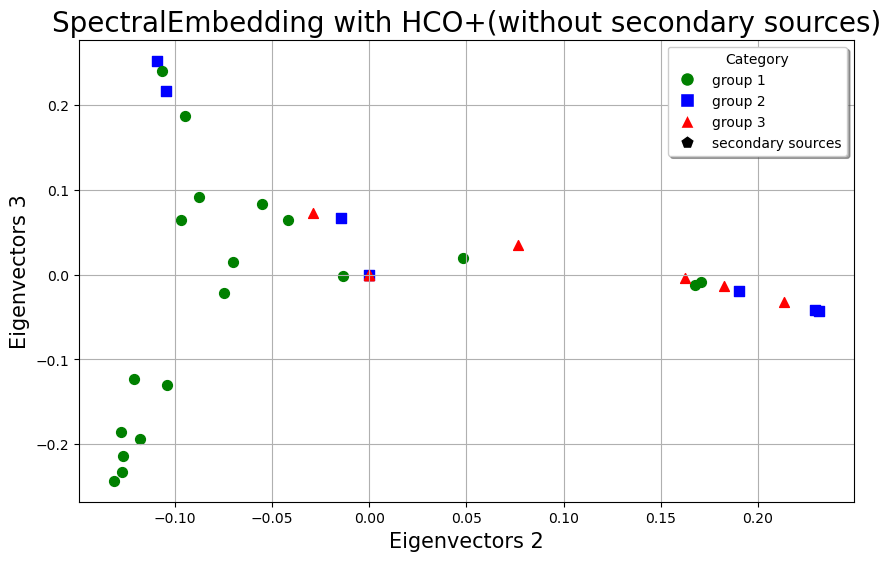

In [82]:
# 与CO的结果进行比较
file_path_color = "data_with_colors(2).txt"

# 假设文件格式：
# 列名: ID   Vsys   RA    Dec
# 数据: 001  250.3  12.5  30.0
# 注释行以 '#' 开头

df_color = pd.read_csv(
    file_path_color,
    sep='\s+',          # 按空格/制表符分隔
    comment='#',        # 忽略注释行
    header=0,           # 第一行为列名
    #names=['ID', 'Vsys', 'RA', 'Dec']  # 可选：手动指定列名
)

# print(df_color) 
na=df_color["name"].tolist()
col=df_color["color"].tolist()
mar=df_color["marker"].tolist()
# print(na)
# print(col)
fig, ax = plt.subplots(figsize=(10,6))
plt.grid()

color0=[]

for i in range(len(digits_spec)):
    count=0
    for j in range(len(na)):
        if name_list[i]==na[j]:
            color0=col[j]
            #print(color0)
            ax.scatter(digits_spec[i, 1], digits_spec[i, 2],color=color0,s=50,marker=mar[j] ,label=name_list[i])
            count=1
            break
    if count==0:
        ax.scatter(digits_spec[i, 1], digits_spec[i, 2],color="black",s=50, label=name_list[i],marker="p")
    
       # plt.scatter(digits_spec[i, 0], digits_spec[i, 1],color="black", label=name_list[i])
        
# color0=np.array(color0)
# plt.scatter(spec_xj[mask_circle], spec_yj[mask_circle], s=200,color=color0[mask_circle],alpha=0.8)
# plt.scatter(spec_xj[mask_triangle], spec_yj[mask_triangle], s=200,color=color0[mask_triangle],alpha=0.8,marker="^")

# new_texts = [plt.text(x_, y_, text, fontsize=12) for x_, y_, text in zip(digits_spec[:, 0], digits_spec[:, 1], name_list)]
# adjust_text(new_texts,arrowprops=dict(arrowstyle='->',color='red',lw=1))

# 手动创建图例条目
legend_elements = [
    plt.Line2D([], [], marker='o', color='w', markerfacecolor='green', markersize=10, label='group 1'),
    plt.Line2D([], [], marker='s', color='w', markerfacecolor='blue', markersize=10, label='group 2'),
    plt.Line2D([], [], marker='^', color='w', markerfacecolor='red', markersize=10, label='group 3'),
    plt.Line2D([], [], marker='p', color='w', markerfacecolor='black', markersize=10, label='secondary sources')
]
plt.legend(handles=legend_elements, title="Category", fontsize=10,frameon=True,shadow=True,)

plt.title("SpectralEmbedding with HCO+(without secondary sources)",fontsize=20)
plt.xlabel("Eigenvectors 2",fontsize=15)
plt.ylabel("Eigenvectors 3",fontsize=15)

plt.savefig('./picture/SpectralEmbedding_out_(Blues)(HCO+)(compareCO).png')
plt.show()

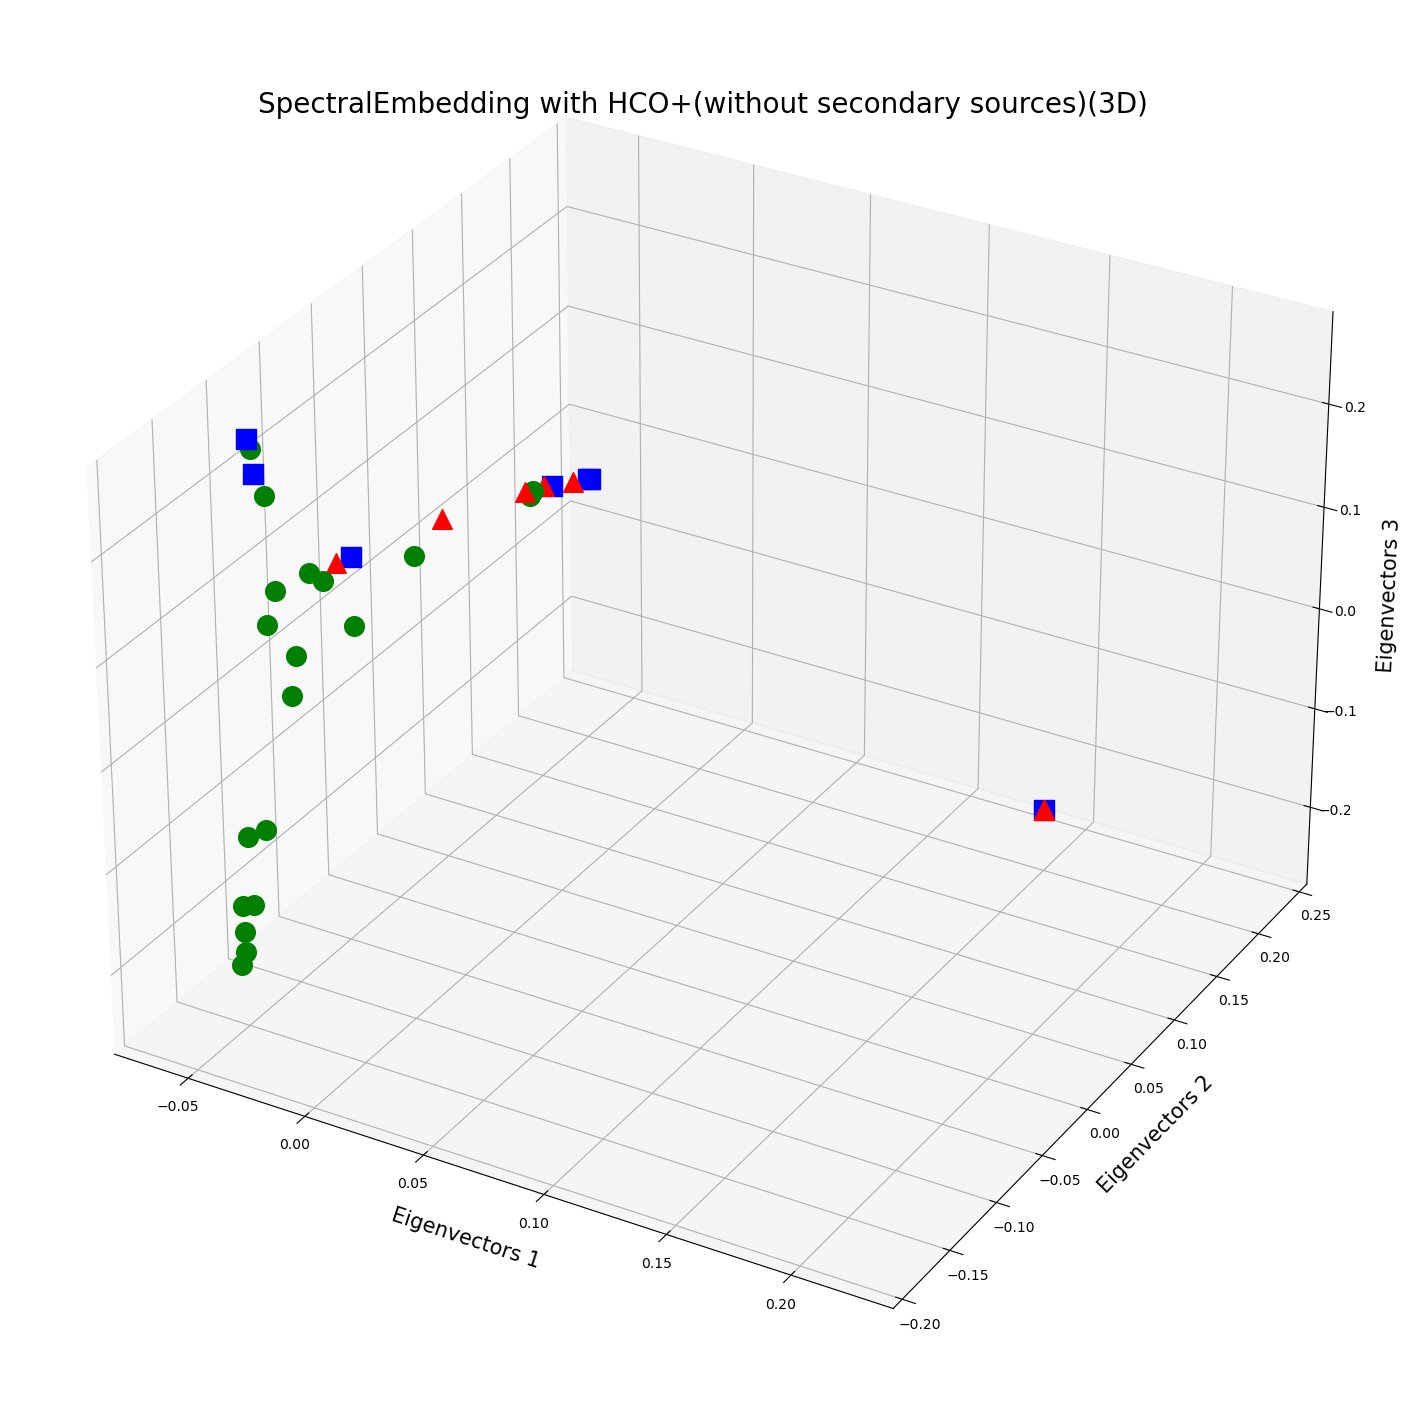

In [81]:
# 与CO去掉次要源的结果进行比较
file_path_color = "data_with_colors(2).txt"

# 假设文件格式：
# 列名: ID   Vsys   RA    Dec
# 数据: 001  250.3  12.5  30.0
# 注释行以 '#' 开头

df_color = pd.read_csv(
    file_path_color,
    sep='\s+',          # 按空格/制表符分隔
    comment='#',        # 忽略注释行
    header=0,           # 第一行为列名
    #names=['ID', 'Vsys', 'RA', 'Dec']  # 可选：手动指定列名
)

# print(df_color) 
na=df_color["name"].tolist()
col=df_color["color"].tolist()
mar=df_color["marker"].tolist()

plt.figure(figsize=(18,18))
ax3 = plt.axes(projection='3d')

for i in range(len(digits_spec)):
    count=0
    for j in range(len(na)):
        if name_list[i]==na[j]:
            color0=col[j]
            #print(color0)
            if name_list[i][0]=="L":
                ax3.scatter3D(digits_spec[i, 0], digits_spec[i, 1],digits_spec[i, 2],color=color0,s=200, label=name_list[i],marker=mar[j])
            elif name_list[i][0]=="S":
                ax3.scatter3D(digits_spec[i, 0], digits_spec[i, 1],digits_spec[i, 2],color=color0,s=200, label=name_list[i],marker=mar[j])
            count=1
            break
    if count==0:
        if name_list[i][0]=="L":
            ax3.scatter3D(digits_spec[i, 0], digits_spec[i, 1],digits_spec[i, 2],color="black",s=200, label=name_list[i],marker="p")
        elif name_list[i][0]=="S":
            ax3.scatter3D(digits_spec[i, 0], digits_spec[i, 1],digits_spec[i, 2],color="black",s=200, label=name_list[i],marker="p")

#plt.legend(loc="center right",ncol=2)
plt.title("SpectralEmbedding with HCO+(without secondary sources)(3D)",fontsize=20,y=1)
ax3.set_ylim([-0.2, 0.25])
ax3.set_xlabel("Eigenvectors 1",fontsize=15,labelpad=10)
ax3.set_ylabel("Eigenvectors 2",fontsize=15,labelpad=10)
ax3.set_zlabel("Eigenvectors 3",fontsize=15,labelpad=10)
plt.savefig('./picture/Compare(HCOout_+vsCOout_).png')
plt.show()

In [35]:
# 求平均谱线
def mean_spec(list7):
    mean=[]
    for i in range(len(list7[0])):  # 数据长度
        mean_data=0
        for j in range(len(list7)):   # 有几组数据
            mean_data+=list7[j][i]
        mean.append(mean_data/len(list7))
    return mean

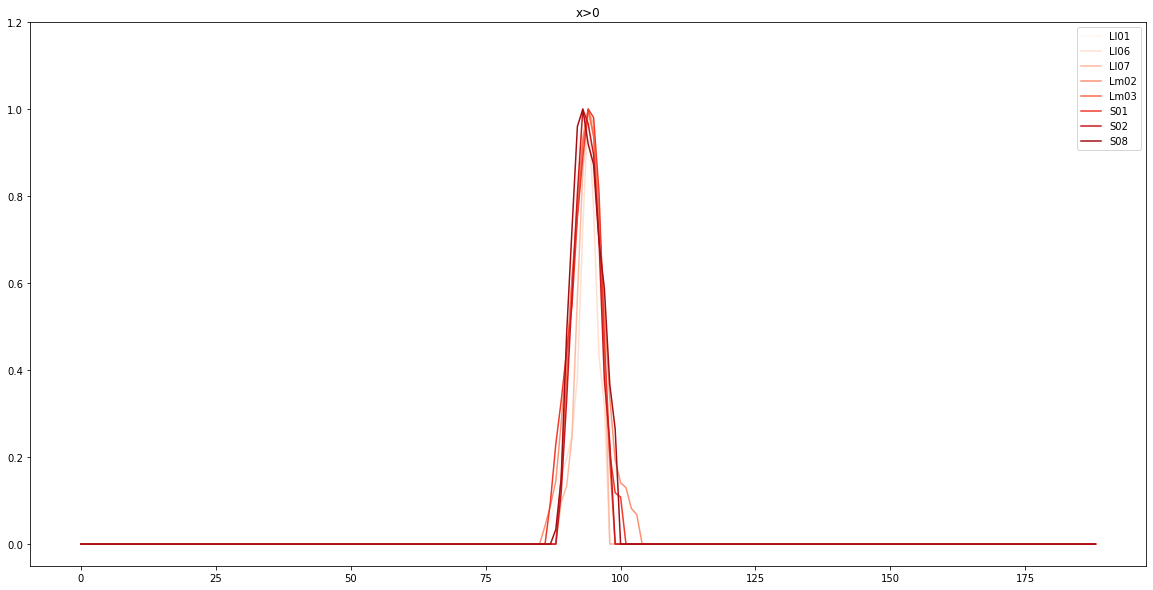

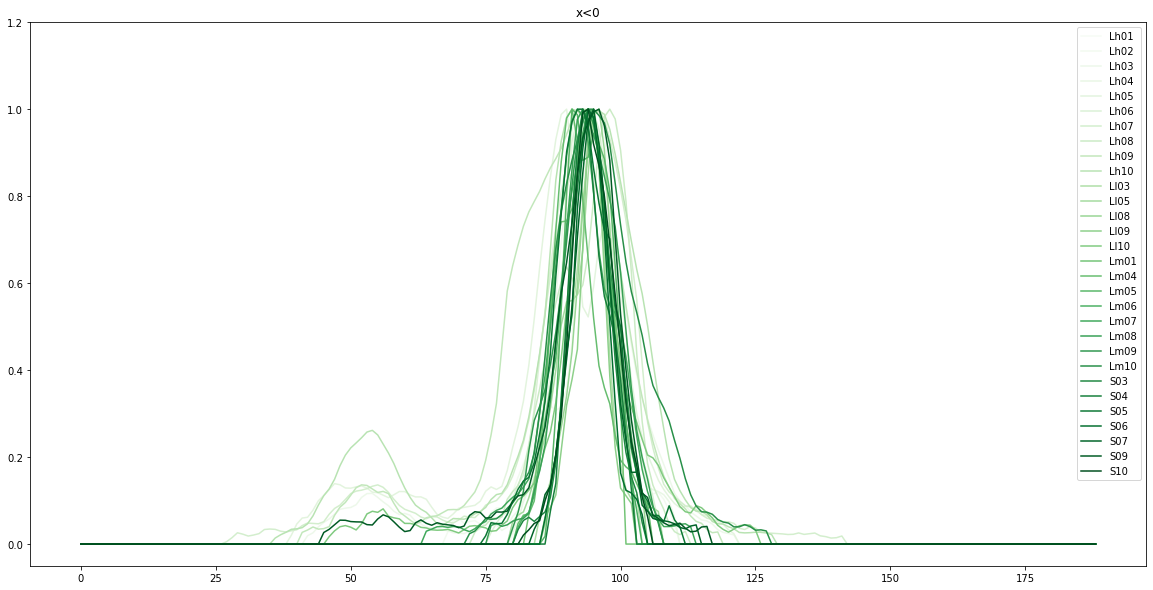

In [38]:
#print(digits_spec)
cate1=[]
name1=[]
cate2=[]
name2=[]
cate3=[]
name3=[]
cate4=[]
name4=[]
mean1=[]
mean2=[]
mean3=[]
mean4=[]
for i in range(len(digits_spec)):
    if digits_spec[i,0]>=0:
        cate1.append(data_flux[i])
        name1.append(name_list[i])
        
    elif digits_spec[i,0]<0:
        cate2.append(data_flux[i])
        name2.append(name_list[i])
        
#     elif -0.025<digits_spec[i,0]<0.05:
#         cate3.append(data_flux[i])
#         name3.append(name_list[i])
        
#     elif digits_spec[i,0]<0.01 and digits_spec[i,1]>0.00:
#         cate4.append(data_flux[i])
#         name4.append(name_list[i])

cmap1=plt.cm.Reds
cmap2=plt.cm.Greens
cmap3=plt.cm.Blues
cmap4=plt.cm.Oranges

# 求平均光谱
# mean1=mean_spec(cate1)
# mean2=mean_spec(cate2)
#mean3=mean_spec(cate3)
#mean4=mean_spec(cate4)

# 画图
plt.figure(figsize=(20,10))
for i in range(len(cate1)): 
    color1 = cmap1(i / len(cate1))
    plt.plot(cate1[i],color=color1,label=name1[i])

plt.ylim(-0.05,1.2)
#plt.plot(mean1,linewidth=10,color="b")
plt.title("x>0")
plt.legend()
plt.show()


plt.figure(figsize=(20,10))
for i in range(len(cate2)):
    color2 = cmap2(i / len(cate2))
    plt.plot(cate2[i],color=color2,label=name2[i])

#plt.plot(mean2,linewidth=10,color="b")
#plt.xlim(25,150)
plt.ylim(-0.05,1.2)
plt.title("x<0")
plt.legend()
plt.show()


# plt.figure(figsize=(20,10))
# for i in range(len(cate3)):
#     color3 = cmap3(i / len(cate3))
#     plt.plot(cate3[i],color=color3,label=name3[i])

# #plt.xlim(25,150)
# plt.ylim(-0.05,1.2)
# plt.plot(mean3,linewidth=10,color="b")
# plt.title("0<x<0.1")
# plt.legend()
# plt.show()


# plt.figure(figsize=(20,10))
# for i in range(len(cate4)):
#     color4 = cmap4(i / len(cate4))
#     plt.plot(cate4[i],color=color4,label=name4[i])

# #plt.xlim(25,150)
# plt.ylim(-0.05,1.2)
# #plt.plot(mean4,linewidth=10,color="b")
# plt.title("x<0 and y>00")
# plt.legend()
# plt.show()

In [47]:
# 计算半高全宽
def calculate_fwhm(x, y, n): # n是取多少高
    # 确保x和y为NumPy数组
    x = np.asarray(x)
    y = np.asarray(y)
    
    # 找到峰值位置
    peak_index = np.argmax(y)
    peak_value = y[peak_index]
    half_max = peak_value*n

    # 处理左侧交点
    i_left = peak_index - 1
    while i_left >= 0 and y[i_left] > half_max:
        i_left -= 1
    
    if i_left < 0:
        raise ValueError("未找到左侧半高交点，请检查数据。")
    if i_left + 1 >= len(y):
        raise ValueError("左侧交点超出范围。")
    
    # 线性插值计算左侧交点x坐标
    dx_left = x[i_left + 1] - x[i_left]
    dy_left = y[i_left + 1] - y[i_left]
    x_left = x[i_left] + (half_max - y[i_left]) * dx_left / dy_left

    # 处理右侧交点
    i_right = peak_index + 1
    while i_right < len(y) and y[i_right] >= half_max:
        i_right += 1
    
    if i_right >= len(y):
        raise ValueError("未找到右侧半高交点，请检查数据。")
    if i_right - 1 < peak_index:
        raise ValueError("右侧交点无效。")
    
    # 线性插值计算右侧交点x坐标
    dx_right = x[i_right] - x[i_right - 1]
    dy_right = y[i_right] - y[i_right - 1]
    x_right = x[i_right - 1] + (half_max - y[i_right - 1]) * dx_right / dy_right
    return x_right - x_left

In [48]:
# 面积
def area(x,y):
    a=np.trapz(y, x)
    return a

In [49]:
# 面积比值
def a_ratio(x,y,n):
# 找到对应高度的横坐标
    # 确保x和y为NumPy数组
    x = np.asarray(x)
    y = np.asarray(y)
    
    # 找到峰值位置
    peak_index = np.argmax(y)
    peak_value = y[peak_index]
    half_max = peak_value*n

    # 处理左侧交点
    i_left = peak_index - 1
    while i_left >= 0 and y[i_left] > half_max:
        i_left -= 1
    
    if i_left < 0:
        raise ValueError("未找到左侧半高交点，请检查数据。")
    if i_left + 1 >= len(y):
        raise ValueError("左侧交点超出范围。")
    
    # 线性插值计算左侧交点x坐标
    dx_left = x[i_left + 1] - x[i_left]
    dy_left = y[i_left + 1] - y[i_left]
    x_left = x[i_left] + (half_max - y[i_left]) * dx_left / dy_left

    # 处理右侧交点
    i_right = peak_index + 1
    while i_right < len(y) and y[i_right] >= half_max:
        i_right += 1
    
    if i_right >= len(y):
        raise ValueError("未找到右侧半高交点，请检查数据。")
    if i_right - 1 < peak_index:
        raise ValueError("右侧交点无效。")
    
    # 线性插值计算右侧交点x坐标
    dx_right = x[i_right] - x[i_right - 1]
    dy_right = y[i_right] - y[i_right - 1]
    x_right = x[i_right - 1] + (half_max - y[i_right - 1]) * dx_right / dy_right
    
# 计算面积
    x_left_int=int(x_left)
    x_right_int=int(x_right)
    left=np.arange(0,x_left_int+1)
    right=np.arange(x_right_int+1,x[-1]+1)
    area_left=np.trapz( y[0:x_left_int+1],left)
    area_right=np.trapz(y[x_right_int+1:x[-1]+1],right)
    area_middle=(x_right-x_left)*half_max
    return area_left+area_right

In [50]:
# 把某部分按x增大顺序排好
sort_x_right=[]    # 按x顺序排列的下面三个列表的组合
cate1_x_right=[]  # 谱线流量
digits_right_x=[]  # 分类结果中该谱线的x值
name_right_x=[]    # 记录谱线的名字

for i in range(len(digits_spec)):
    #if digits_spec[i,0]>0 :
    digits_right_x.append(digits_spec[i,1])
    cate1_x_right.append(data_flux[i])
    name_right_x.append(name_list[i])
        
        
x_right=zip(digits_right_x,cate1_x_right,name_right_x)
sorted_x_right = sorted(x_right,key=lambda x:x[0])
result = zip(*sorted_x_right)
sorted_right_x, sorted_right_flux,sorted_right_name = [list(x) for x in result]  # 按x增大顺序排列的x值，谱线流量，谱线名字

print(len(sorted_right_flux))

38


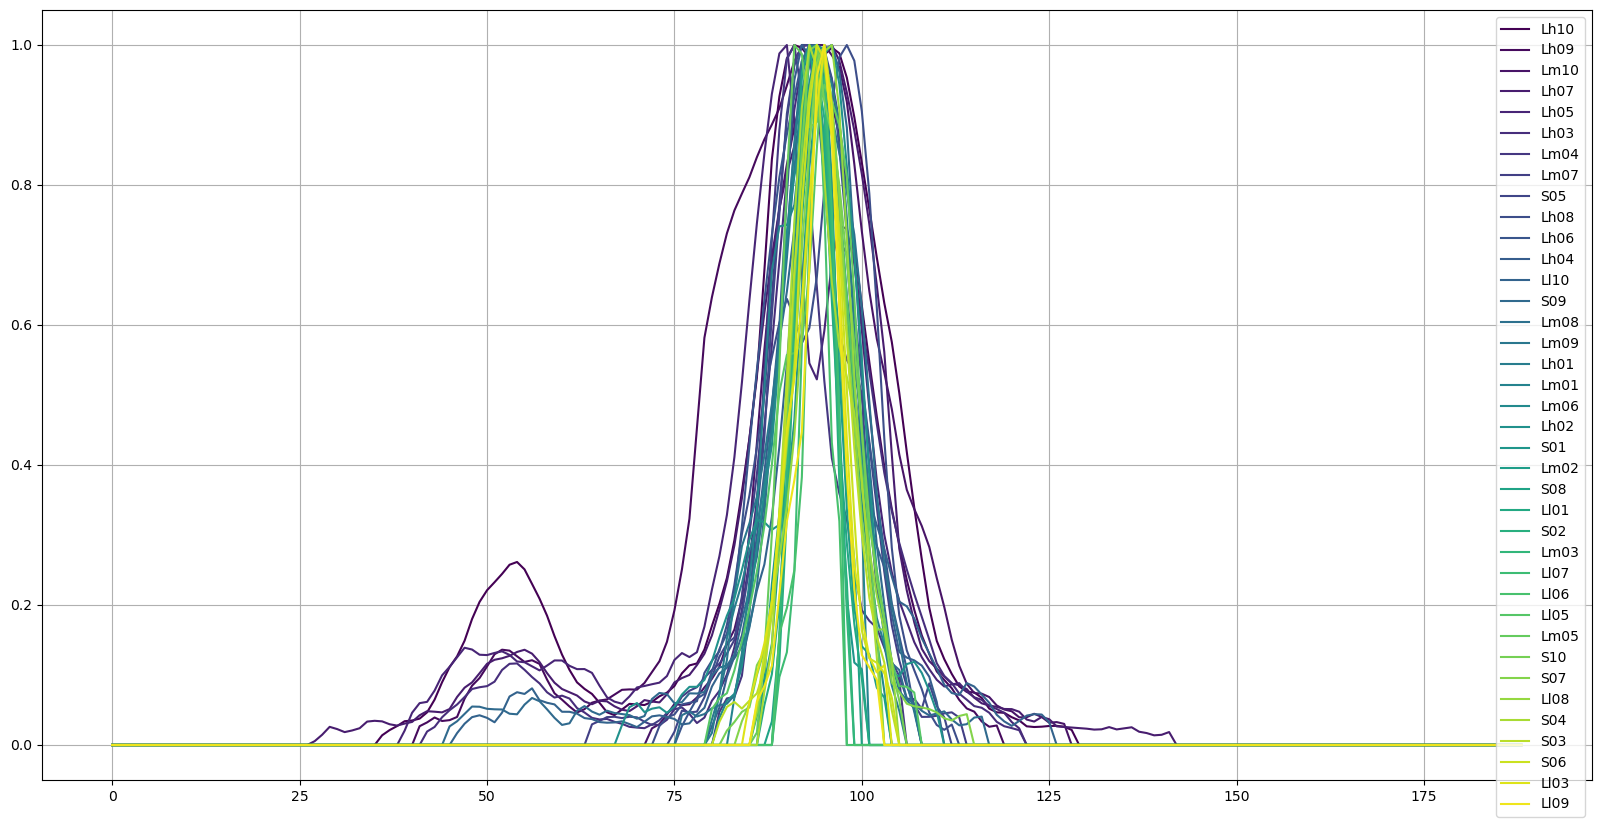

In [51]:
# 画图
cmap = plt.cm.viridis
plt.figure(figsize=(20,10))

for i in range(len(sorted_right_flux)):   # 算各种物理量
    
    
    color = cmap(i / len(sorted_right_flux))
    plt.plot(sorted_right_flux[i],color=color,label=sorted_right_name[i])
    #plt.title("x value:{}".format(sorted_so2_x[i]))
    #plt.title("name:{}".format(sorted_so2_name[i]))
    #plt.savefig('./picture/sorted_x-{}.png'.format(i + 1))


plt.legend(loc="upper right")
plt.grid()
plt.show()

#print(linewidth_x)

In [52]:
def calculate_peak_valley_differences(spectrum, prominence_threshold=5):
    """
    计算光谱中两个主峰与它们之间的谷值的高度差。
    
    参数:
        spectrum (np.ndarray): 一维数组，表示光谱数据。
        prominence_threshold (float): 峰的最小突出度阈值。
        
    返回:
        (diff_left, diff_right, valley_idx): 左峰与谷的高度差，右峰与谷的高度差，谷的位置索引。
        如果没有找到足够峰，返回(None, None, None)。
    """
    # 检测峰及其突出度
    peaks, properties = find_peaks(spectrum, prominence=prominence_threshold)
    
    if len(peaks) < 2:
        return 0, 0, 0  # 不足两个峰
    
    # 根据突出度选择前两个主峰
    prominences = properties['prominences']
    peak_indices = sorted(zip(prominences, peaks), key=lambda x: -x[0])[:2]
    selected_peaks = sorted([pi[1] for pi in peak_indices])  # 按位置排序
    
    left_peak, right_peak = selected_peaks
    
    # 查找两个峰之间的谷值
    valley_segment = spectrum[left_peak:right_peak + 1]
    valley_rel_idx = np.argmin(valley_segment)
    valley_idx = left_peak + valley_rel_idx
    
    # 计算高度差
    diff_left = spectrum[left_peak] - spectrum[valley_idx]
    diff_right = spectrum[right_peak] - spectrum[valley_idx]
    
    return diff_left, diff_right, valley_idx


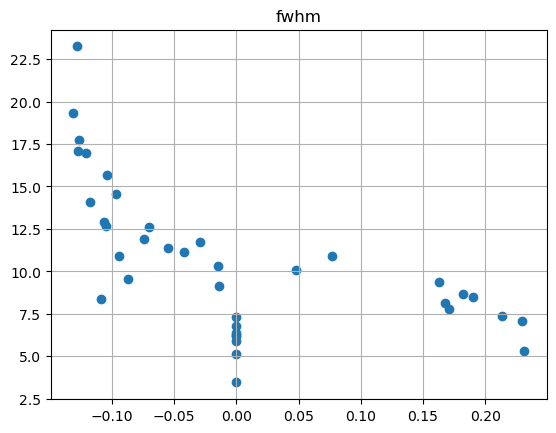

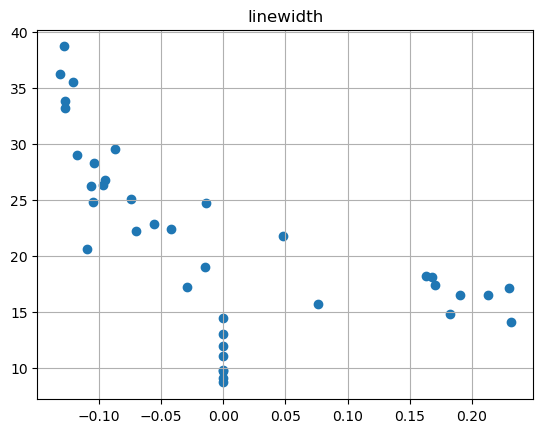

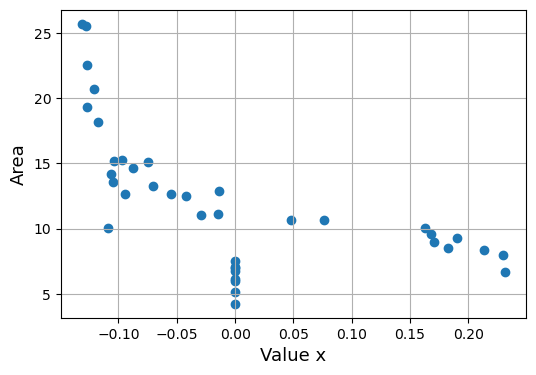

In [54]:
fwhm_full=[]
linewidth_full=[]
area_full=[]
# area_full2=[]
flux_x = np.arange(0, len(sorted_right_flux[1]),1)
#print(flux_x)
for i in range(len(sorted_right_flux)):
    fwhm=calculate_fwhm(flux_x,sorted_right_flux[i],0.5)
    fwhm_full.append(fwhm)
    linewid=calculate_fwhm(flux_x,sorted_right_flux[i],0.1)
    linewidth_full.append(linewid)
    area_full.append(area(flux_x,sorted_right_flux[i]))
#     area2 = simpson_integral(flux_x,sorted_flux[i])
#     area_full2.append(area2)

# 画出所有谱线x值和不同属性的散点图
plt.scatter(sorted_right_x,fwhm_full)
#plt.xlim(0.05,0.16)
plt.title("fwhm")
plt.grid()
plt.show()

plt.scatter(sorted_right_x,linewidth_full)
#plt.xlim(0.05,0.16)
plt.title("linewidth")
plt.grid()
plt.show()

#-------------------论文插图------------------------
plt.figure(figsize=(6,4))
plt.scatter(sorted_right_x,area_full)
#plt.xlim(0.05,0.16)
plt.xlabel("Value x",fontsize=13)
plt.ylabel("Area",fontsize=13)
plt.grid()
plt.savefig('C:/Users/zyx/Desktop/all-picture/4.21.png')
plt.show()
#--------------------------------------------------

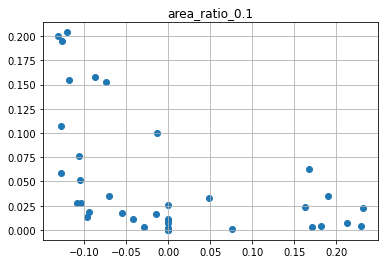

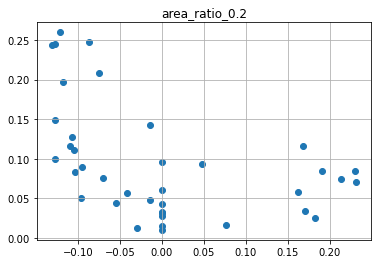

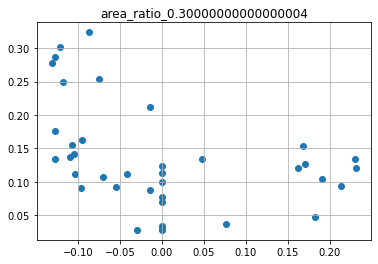

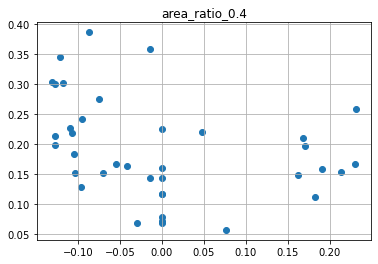

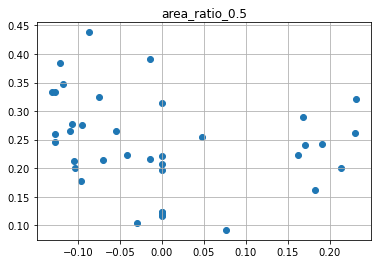

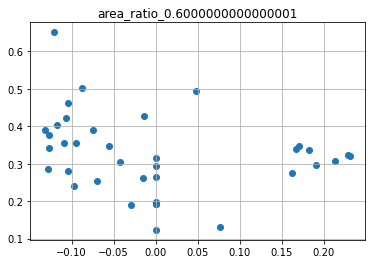

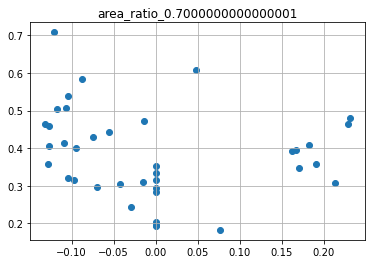

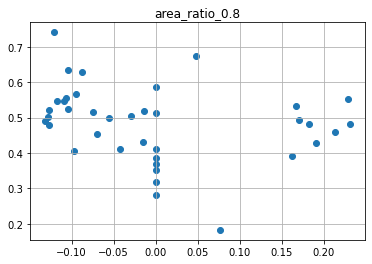

In [53]:
# 面积比例
for n in range(1,9):
    area_ratio=[]
    for i in range(len(sorted_right_x)):
        area_ratio.append(a_ratio(flux_x,sorted_right_flux[i],n*0.1)/area(flux_x,sorted_right_flux[i]))
    plt.scatter(sorted_right_x,area_ratio)
    #plt.xlim(0.05,0.16)
    plt.title("area_ratio_{}".format(n*0.1))
    plt.grid()
    plt.show()

In [54]:
# 把某部分按y增大顺序排好
sort_y=[]    # 按y顺序排列的下面三个列表的组合
cate1_y=[]  # 谱线流量
digits_y=[]  # 分类结果中该谱线的x值
name_y=[]    # 记录谱线的名字

for i in range(len(digits_spec)):
#     if digits_spec[i,0]<0 :
    digits_y.append(digits_spec[i,2])
    cate1_y.append(data_flux[i])
    name_y.append(name_list[i])
        
        
y_=zip(digits_y,cate1_y,name_y)
sort_y = sorted(y_,key=lambda x:x[0])
result_y = zip(*sort_y)
sorted_y, sorted_y_flux,sorted_y_name = [list(x) for x in result_y]  # 按x增大顺序排列的x值，谱线流量，谱线名字

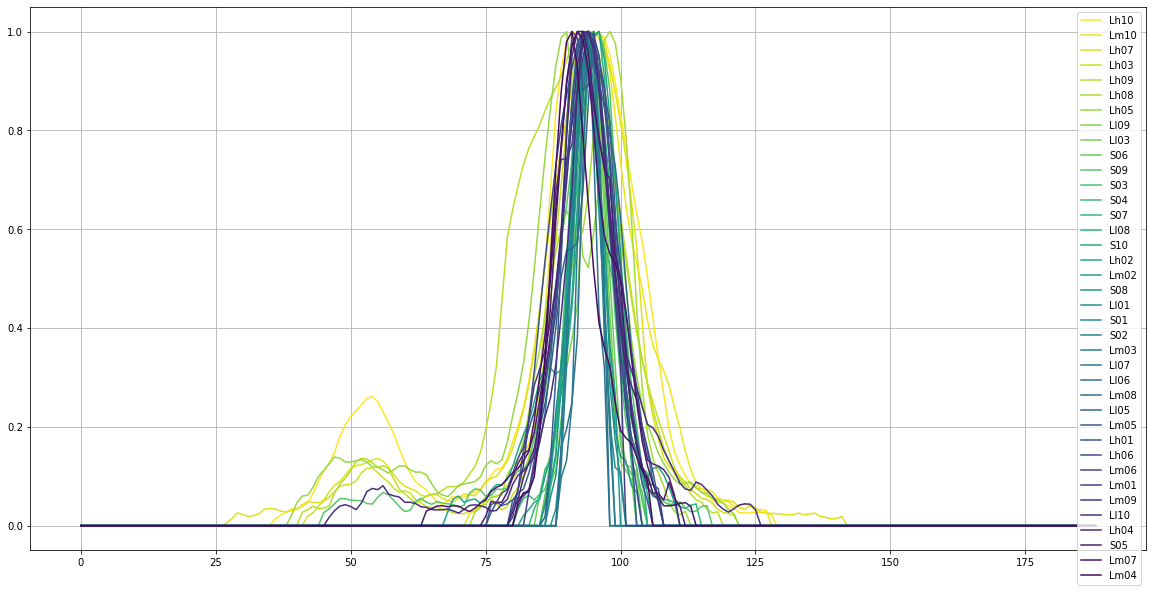

In [55]:
cmap = plt.cm.viridis_r
plt.figure(figsize=(20,10))

for i in range(len(sorted_y_flux)):   # 算各种物理量
    
    
    color = cmap(i / len(sorted_y_flux))
    plt.plot(sorted_y_flux[i],color=color,label=sorted_y_name[i])
    #plt.title("x value:{}".format(sorted_so2_x[i]))
    #plt.title("name:{}".format(sorted_so2_name[i]))
    #plt.savefig('./picture/sorted_x-{}.png'.format(i + 1))


plt.legend(loc="upper right")
plt.grid()
plt.show()

#print(linewidth_x)

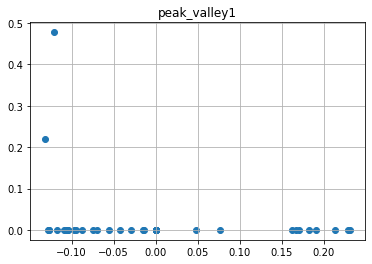

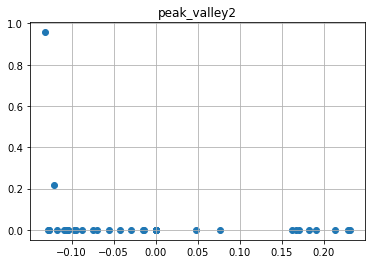

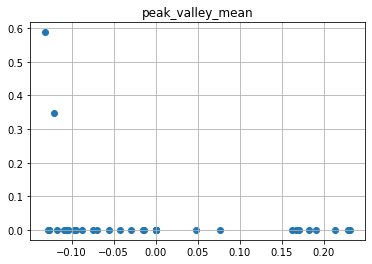

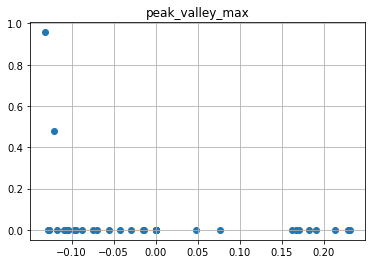

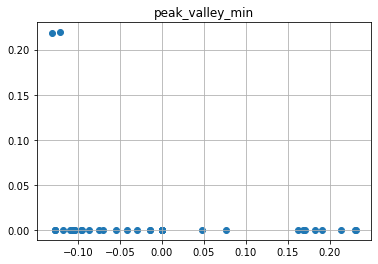

In [51]:
peak_valley1=[]
peak_valley2=[]
peak_valley_mean=[]
peak_valley_max=[]
peak_valley_min=[]

for i in range(len(sorted_y)):
    diff_l,diff_r,valley_i=calculate_peak_valley_differences(sorted_y_flux[i], prominence_threshold=0.1)
    peak_valley1.append(diff_l)
    peak_valley2.append(diff_r)
    peak_valley_mean.append((diff_l+diff_r)/2)
    peak_valley_max.append(max(diff_l,diff_r))
    peak_valley_min.append(min(diff_l,diff_r))
#     plt.plot(sorted_y_flux[i])
#     print("第{}个光谱的峰深为：".format(i),diff_l,diff_r)
#     plt.show()

plt.scatter(sorted_y,peak_valley1)
#plt.xlim(0.05,0.16)
plt.title("peak_valley1")
plt.grid()
plt.show()

plt.scatter(sorted_y,peak_valley2)
#plt.xlim(0.05,0.16)
plt.title("peak_valley2")
plt.grid()
plt.show()

plt.scatter(sorted_y,peak_valley_mean)
#plt.xlim(0.05,0.16)
plt.title("peak_valley_mean")
plt.grid()
plt.show()

plt.scatter(sorted_y,peak_valley_max)
#plt.xlim(0.05,0.16)
plt.title("peak_valley_max")
plt.grid()
plt.show()

plt.scatter(sorted_y,peak_valley_min)
#plt.xlim(0.05,0.16)
plt.title("peak_valley_min")
plt.grid()
plt.show()

In [56]:
# 均方根
def ruggedness_rms(y):
    dy = np.diff(y)
    return np.sqrt(np.mean(dy**2))

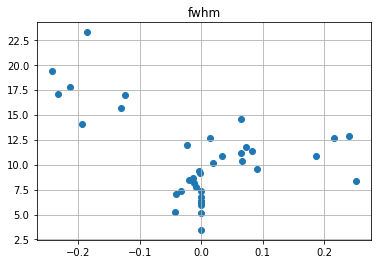

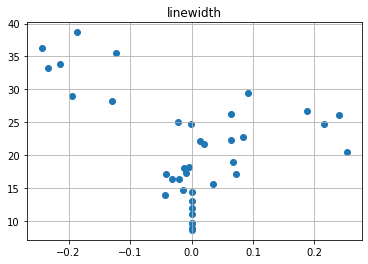

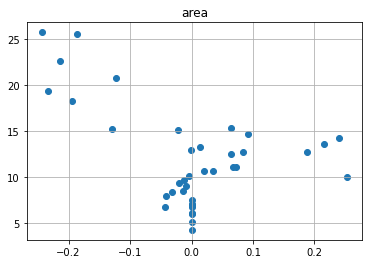

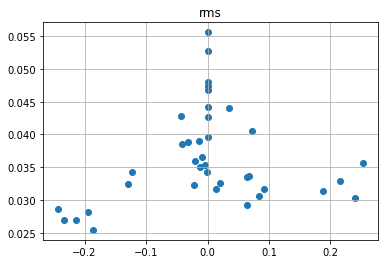

In [57]:
fwhm_y=[]
linewidth_y=[]
area_y=[]
rms_y=[]
# area_full2=[]
flux_x = np.arange(0, len(sorted_right_flux[1]),1)
#print(flux_x)
for i in range(len(sorted_y_flux)):
    fwhmy=calculate_fwhm(flux_x,sorted_y_flux[i],0.5)
    fwhm_y.append(fwhmy)
    linewidy=calculate_fwhm(flux_x,sorted_y_flux[i],0.1)
    linewidth_y.append(linewidy)
    area_y.append(area(flux_x,sorted_y_flux[i]))
    rms_y.append(ruggedness_rms(sorted_y_flux[i]))
#     area2 = simpson_integral(flux_x,sorted_flux[i])
#     area_full2.append(area2)

# 画出所有谱线x值和不同属性的散点图
plt.scatter(sorted_y,fwhm_y)
#plt.xlim(0.05,0.16)
plt.title("fwhm")
plt.grid()
plt.show()

plt.scatter(sorted_y,linewidth_y)
#plt.xlim(0.05,0.16)
plt.title("linewidth")
plt.grid()
plt.show()

plt.scatter(sorted_y,area_y)
#plt.xlim(0.05,0.16)
plt.title("area")
plt.grid()
plt.show()

plt.scatter(sorted_y,rms_y)
#plt.xlim(0.05,0.16)
plt.title("rms")
plt.grid()
plt.show()

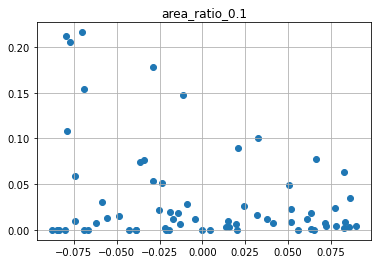

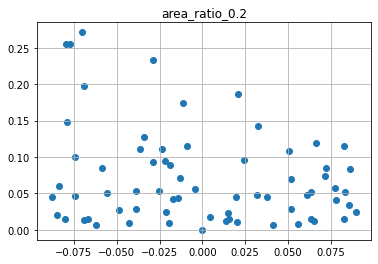

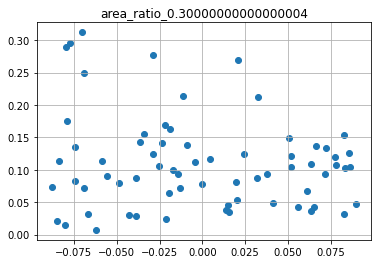

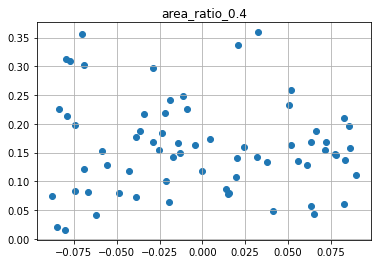

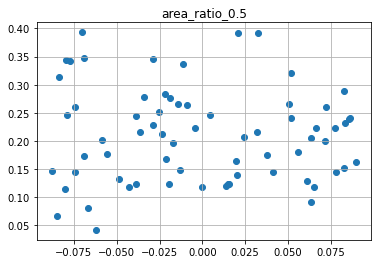

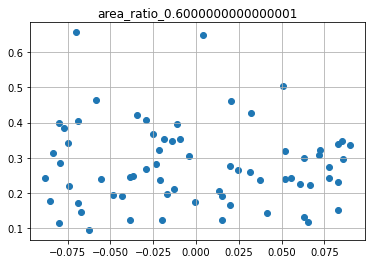

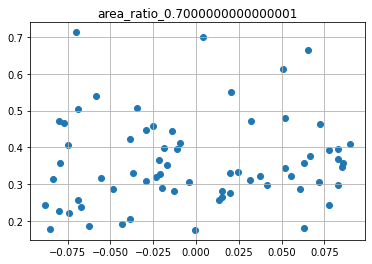

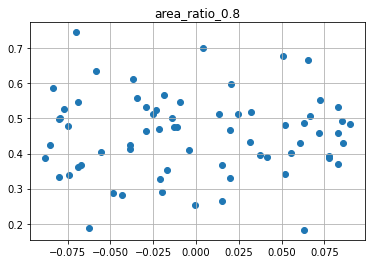

In [42]:
flux_x = np.arange(0, len(sorted_y_flux[1]),1)
for n in range(1,9):
    area_full_y=[]
    area_ratio_y=[]
    for i in range(len(sorted_y)):
        area_full_y.append(area(flux_x,sorted_y_flux[i]))
        area_ratio_y.append(a_ratio(flux_x,sorted_y_flux[i],n*0.1)/area(flux_x,sorted_y_flux[i]))
    plt.scatter(sorted_y,area_ratio_y)
    #plt.xlim(0.05,0.16)
    plt.title("area_ratio_{}".format(n*0.1))
    plt.grid()
    plt.show()

In [44]:
print(1e-10)

1e-10
